# EDA
El objetivo de este notebook es realizar un análisis explorativo de datos, y usar los resultados de este análisis para limpiar más los datos y/o preprocesarlos

In [75]:
from sklearn.impute import SimpleImputer
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from sklearn.decomposition import PCA

from notebooks.preprocessing_draft import standardize_features, log_transform_features, cap_outliers
from src.constants import COLS, DEV_SET_CLEAN_PATH, TARGET, DevSetType
from src.plots import plot_correlation_heatmap, plot_histograms, plot_bar_charts, plot_geo_scatterplot, \
    plot_categorical_impact, plot_median_price_impact, plot_feature_impact_ranking, plot_missing_values, \
    plot_missing_data_impact, plot_interaction, plot_numeric_vs_target, plot_boolean_percentage, plot_pca_scatter
from src.utils import get_dev_set

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
df = get_dev_set(DevSetType.CLEAN)

In [28]:
df.describe(include="all")

,id_grid,STotalM2,SConstrM2,Dormitorios,Banos,Ambientes,Amoblado,Antiguedad,Cisterna,BusinessCenter,...,ITE_ADD_CITY_NAME,ITE_ADD_STATE_NAME,ITE_ADD_NEIGHBORHOOD_NAME,ITE_TIPO_PROD,LONGITUDE,LATITUDE,precio_pesos_constantes,year,SUM,mes_listing
count,270722.000000,2.625700e+05,2.637110e+05,270600.000000,270720.000000,269372.000000,240404,2.462170e+05,186007,203480,...,270722,270722,258101,270722,270722.000000,270722.000000,2.707220e+05,270722.000000,214481,270722.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,2,2,...,39,4,503,3,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,False,...,Capital Federal,Capital Federal,Palermo,U,NaN,NaN,NaN,NaN,False,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,220228,NaN,185078,202323,...,153713,153873,15541,198208,NaN,NaN,NaN,NaN,176426,NaN
mean,59783.531427,3.966844e+03,1.720577e+03,1.415525,1.335317,2.402859,NaN,2.907282e+01,NaN,NaN,...,NaN,NaN,NaN,NaN,-58.481009,-34.598212,8.215245e+04,2021.472185,NaN,6.521214
std,14743.230060,9.779750e+05,4.121328e+05,1.025420,1.030380,1.391790,NaN,4.419451e+03,NaN,NaN,...,NaN,NaN,NaN,NaN,0.115100,0.081543,6.757263e+05,0.499227,NaN,3.439359
min,124.000000,1.000000e+00,1.000000e+00,0.000000,0.000000,1.000000,NaN,0.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,-58.874595,-34.923504,4.264038e+01,2021.000000,NaN,1.000000
25%,53517.000000,3.900000e+01,3.700000e+01,1.000000,1.000000,2.000000,NaN,0.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,-58.543363,-34.632289,6.568300e+03,2021.000000,NaN,4.000000
50%,60080.000000,5.000000e+01,4.600000e+01,1.000000,1.000000,2.000000,NaN,7.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,-58.449924,-34.597885,9.166979e+03,2021.000000,NaN,7.000000
75%,65657.000000,7.800000e+01,7.000000e+01,2.000000,1.000000,3.000000,NaN,3.000000e+01,NaN,NaN,...,NaN,NaN,NaN,NaN,-58.400915,-34.566651,1.866683e+04,2022.000000,NaN,9.000000


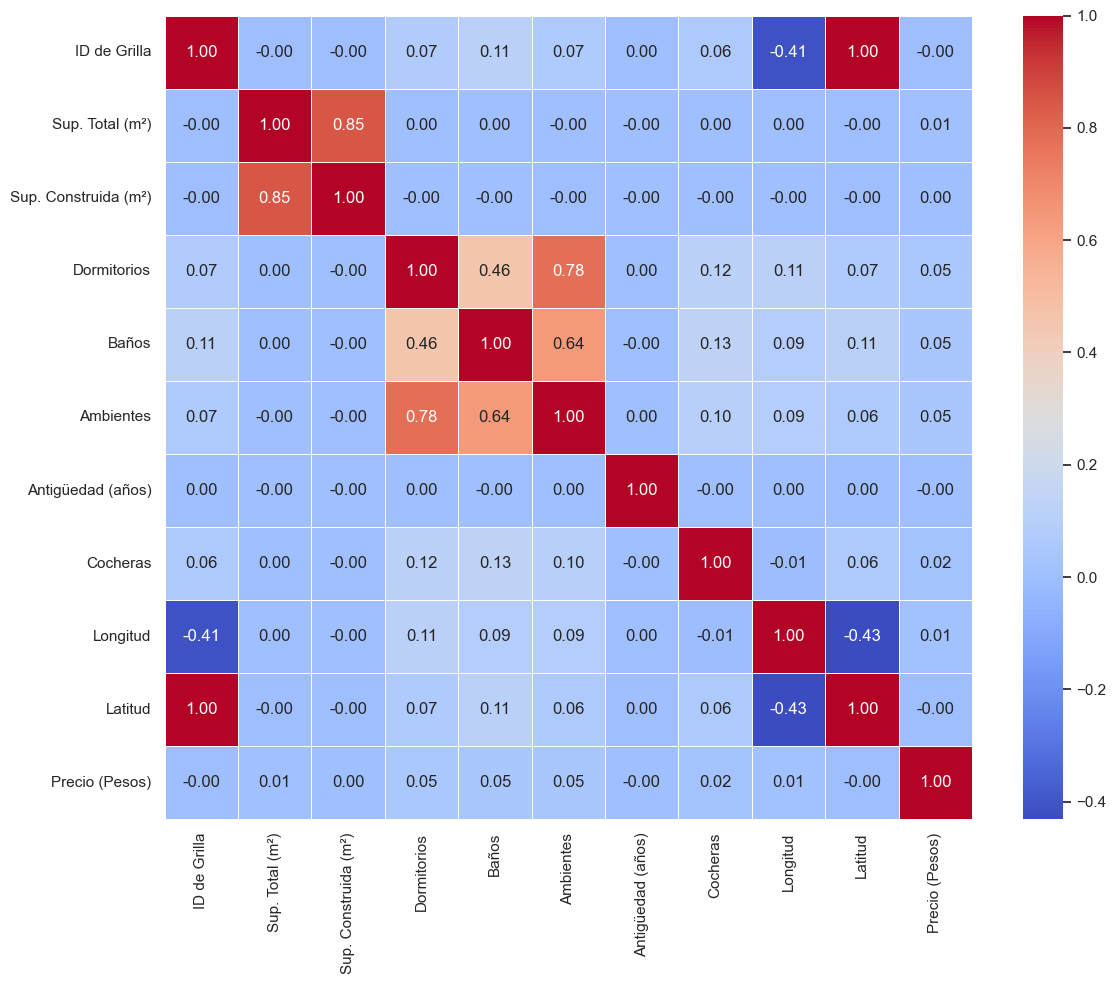

In [29]:
NUMERICAL_FEATURES = [
    COLS.ID_GRID, 
    COLS.SUP_TOTAL, 
    COLS.SUP_CONSTR, 
    COLS.DORMITORIOS, 
    COLS.BANOS, 
    COLS.AMBIENTES, 
    COLS.ANTIGUEDAD,
    COLS.COCHERAS,
    COLS.LONGITUD,
    COLS.LATITUD,
]
plot_correlation_heatmap(df, NUMERICAL_FEATURES + [COLS.TARGET])

A priori, no hay correlación alguna entre las variables y el target, para ninguna feature. Esto probablemente se deba a outliers extremos, escalas muy diferentes, distribuciones sesgadas, o simplemente que la correlacion es no lineal. Tenemos que trabajar el dataset antes de seguir analizando

## Análisis de Precio
Análicemos un poco la variable objetivo:

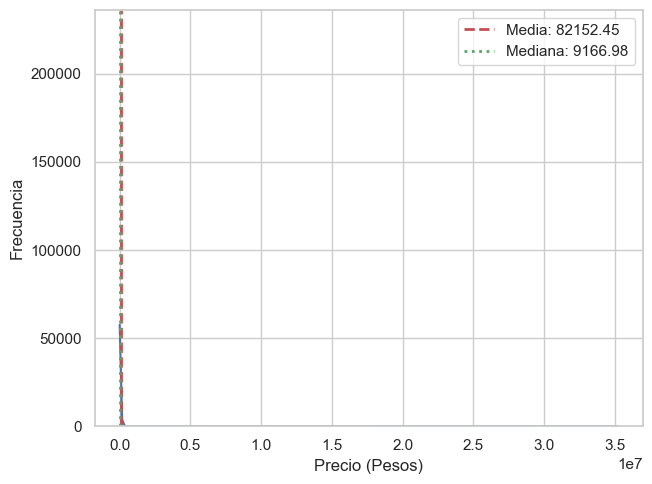

In [30]:
plot_histograms(df, [COLS.TARGET], filename="eda/03-distribucion-precio-original")

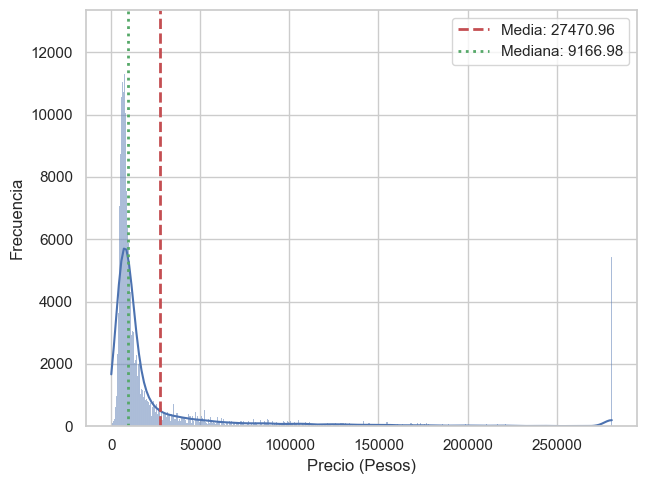

In [31]:
plot_histograms(df, [COLS.TARGET], clip_percentiles=(0.00, 0.98), filename="eda/03-distribucion-precio-clipped")

La variable objetivo (precio) está extremadamente sesgada hacia la izquierda. Esto quiere decir que la mayoría de los precios se encuentran en esa zona, mientras que hay unas pocas propiedades que tienen precios extremadamente altos. Veamos qué pasa si aplicamos el log:

In [32]:
df_log_precio = log_transform_features(df, [COLS.TARGET])

Applying log transformation to columns: precio_pesos_constantes


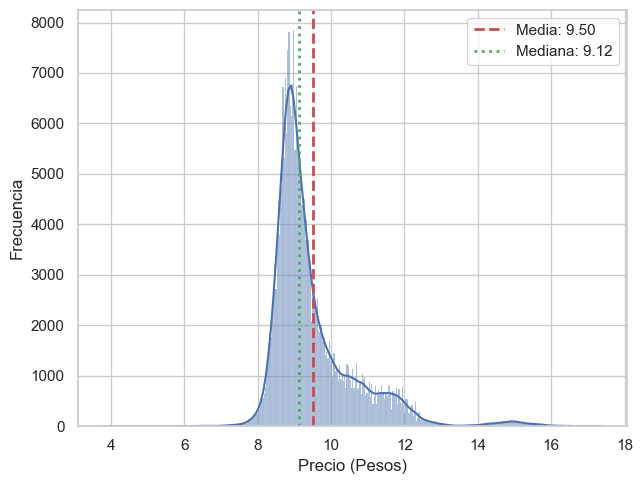

In [33]:
plot_histograms(df_log_precio, [COLS.TARGET], filename="eda/03-distribucion-precio-log")

La distribución de log(precio) es mucho más simpetrica y parecida a una distribución normal. Vamos a hacer que nuestro modelo prediga log(precio), lo cual va a facilitar mucho las predicciones.

## Análisis de Features Numéricas
Analicemos la distribución del resto de features numéricas:

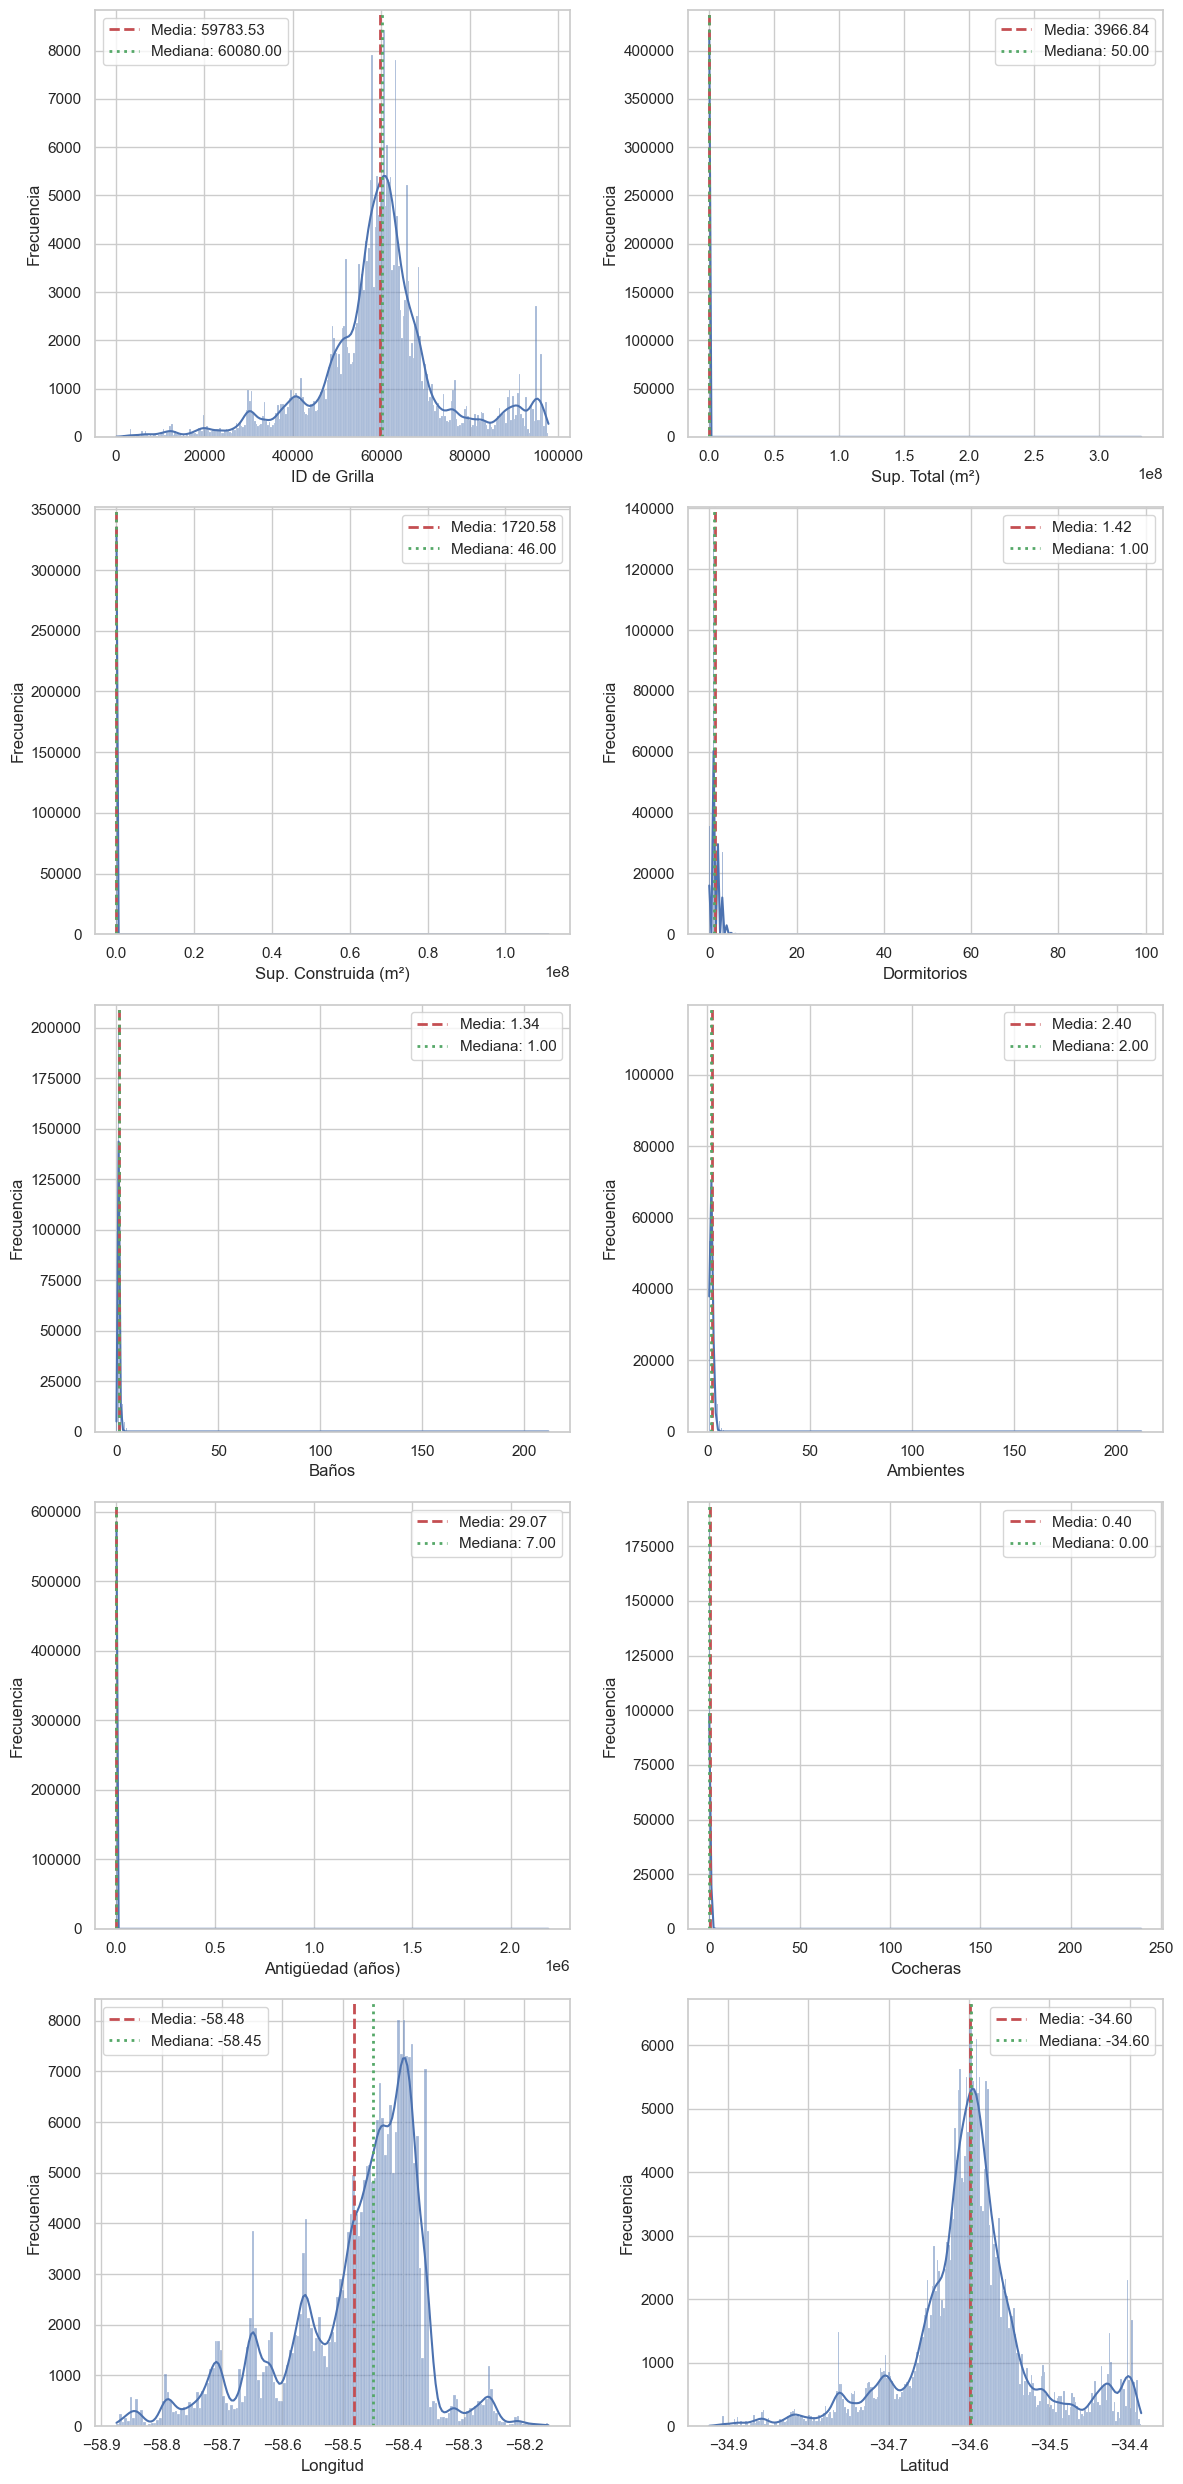

In [34]:
plot_histograms(df_log_precio, NUMERICAL_FEATURES, n_cols=2)

La mayoría de features muestran una asimetría extrema.

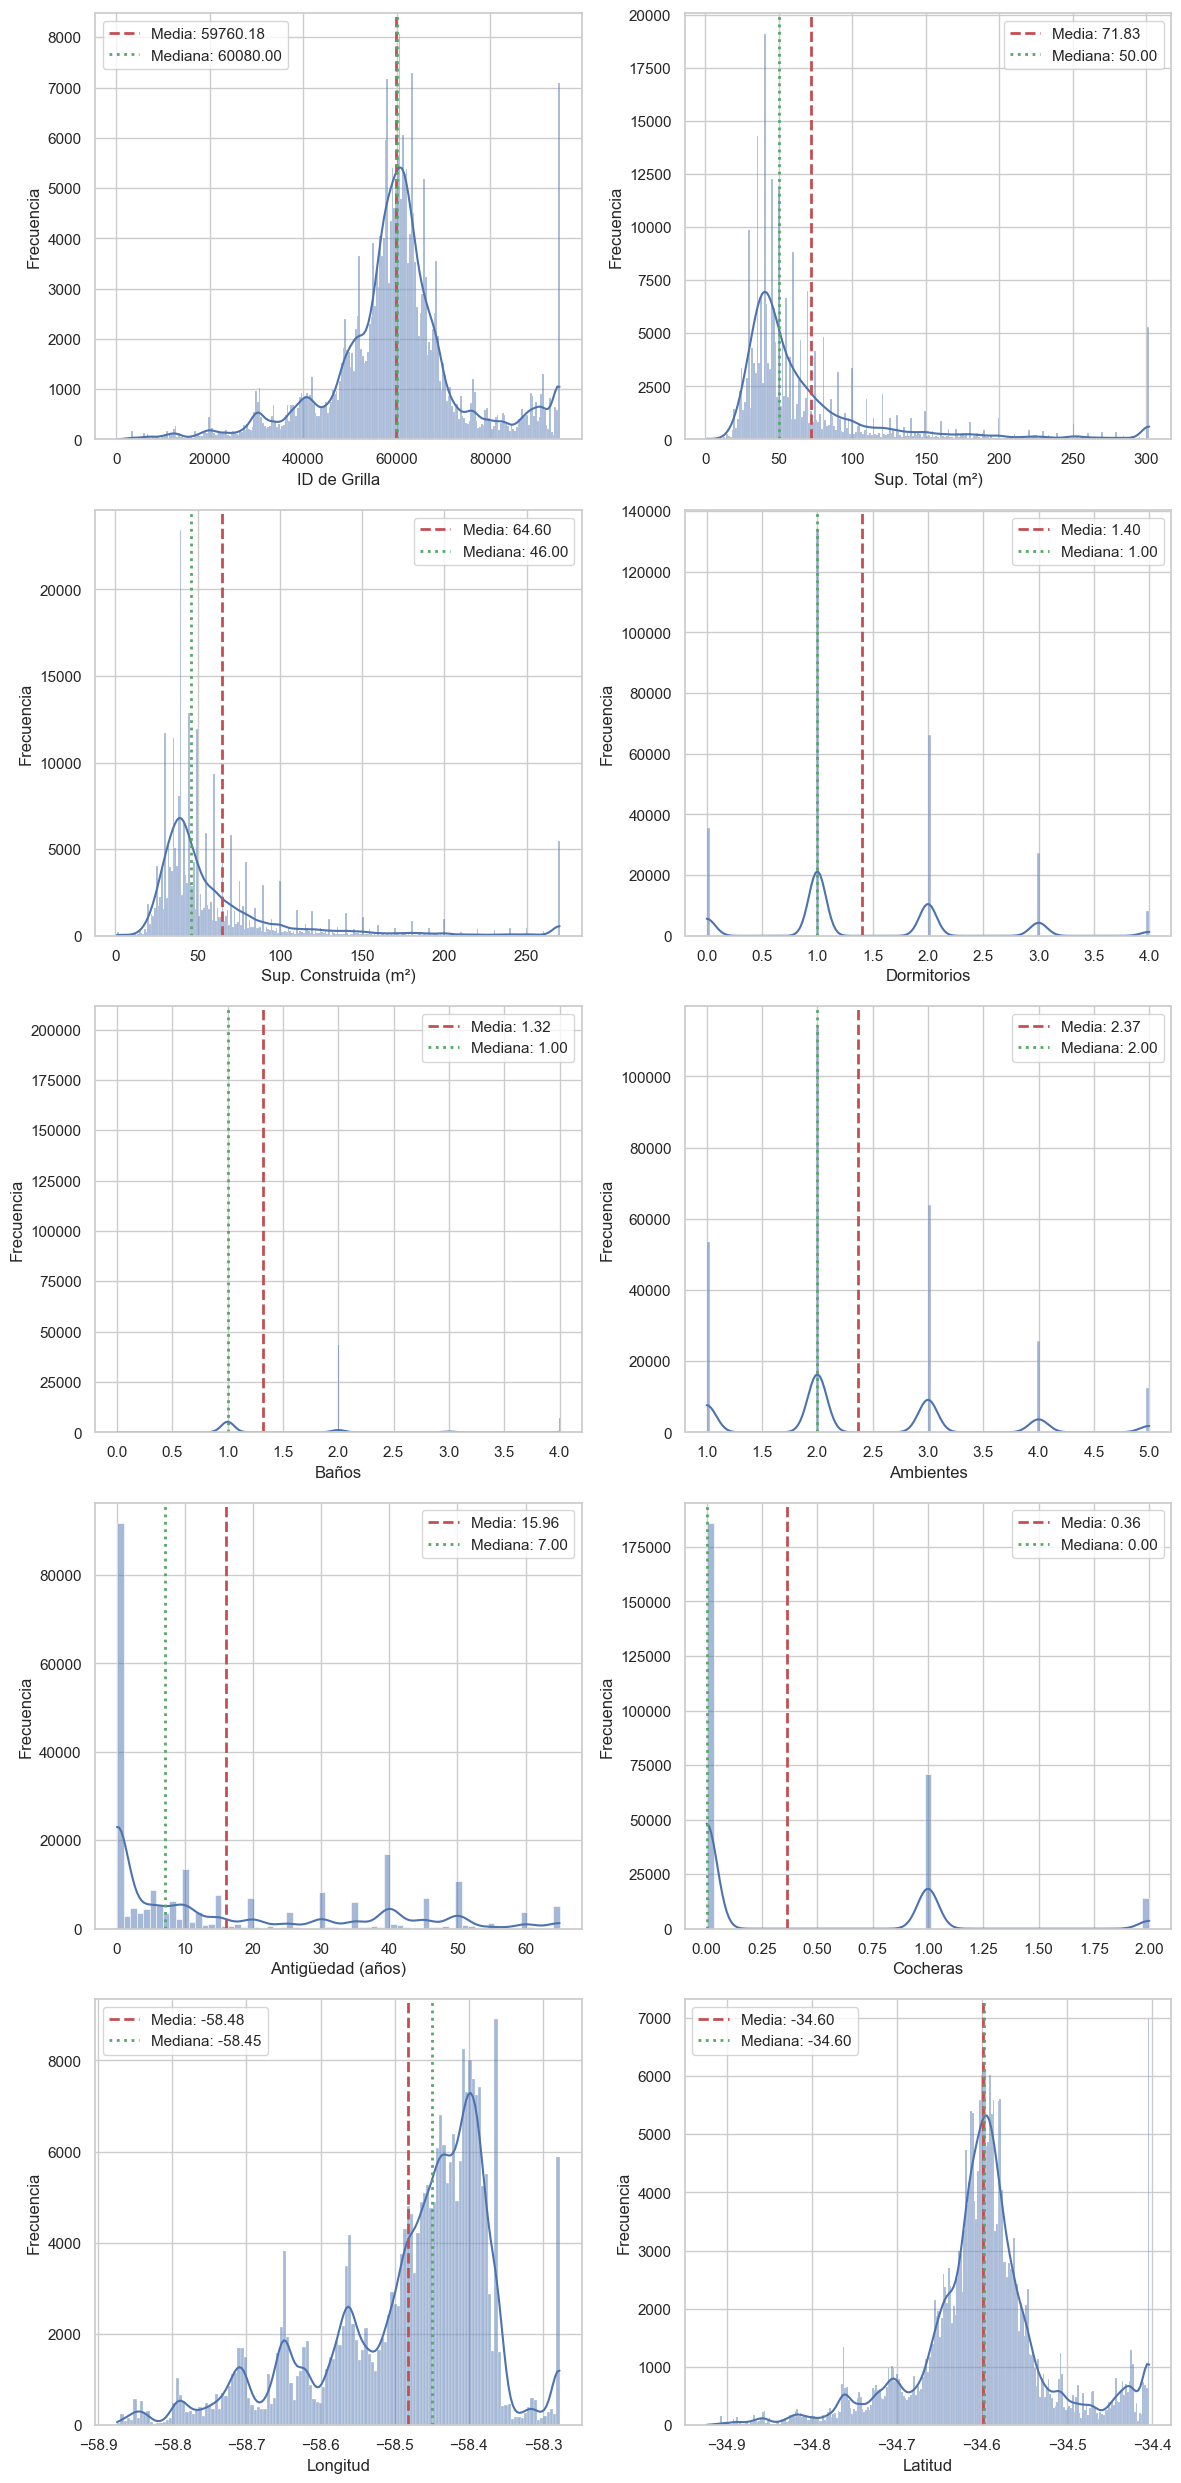

In [35]:
plot_histograms(df_log_precio, NUMERICAL_FEATURES, clip_percentiles=(0.00, 0.98), n_cols=2)

Al excluir los valores realmente extremos, vemos que muchas variables pasan de ser aparentemente numéricas a categóricas. Esto sucede con Dormitorios, Banos, Ambientes, Cocheras. Al excluir outliers extremos, estas variables se mueven únicamente en valores discretos entre 0 y 6. Por ello, asumimos que esos valores extremos (que aplican solo a algunos datos) son erróneos. Vamos a capearlos al percentil más cercano

In [36]:
OUTLIER_COLS = [COLS.DORMITORIOS, COLS.BANOS, COLS.AMBIENTES, COLS.COCHERAS, COLS.ANTIGUEDAD]
df_capped, _ = cap_outliers(df_log_precio, OUTLIER_COLS, percentiles=(0.00, 0.98))

Capping outliers for columns: Dormitorios, Banos, Ambientes, Cocheras, Antiguedad


Además, actualizamos nuestras columnas numéricas para no incluir las recién nombradas (pues pasan a ser categóricas al tener solo algunos valores posibles)

In [37]:
NUMERICAL_FEATURES = [
    COLS.ID_GRID, COLS.SUP_TOTAL, COLS.SUP_CONSTR, COLS.ANTIGUEDAD, COLS.LONGITUD, COLS.LATITUD,
]

CATEGORICAL_FEATURES = [
    COLS.DORMITORIOS, COLS.BANOS, COLS.AMBIENTES, COLS.AMOBLADO, COLS.BUSINESS, COLS.GIMNASIO, COLS.LAUNDRY, COLS.CALEFACCION, COLS.AIRE, COLS.RECEPCION, COLS.ESTACIONAMIENTO, COLS.JACUZZI, COLS.SEGURIDAD, COLS.PILETA, COLS.COCHERAS, COLS.TENNIS, COLS.PROVINCIA, COLS.CONDICION, COLS.BARRIO, COLS.ANIO, COLS.MES, COLS.SUM, COLS.JUEGOS, COLS.CISTERNA
]

Todavía tenemos problemas con algunas variables numéricas. Por ejemplo, la superficie y antigüedad están muy sesgadas y afectadas por outliers. Veamos si aplicar una transformación logarítmica ayuda a mejorar esto

Applying log transformation to columns: STotalM2, SConstrM2, Antiguedad


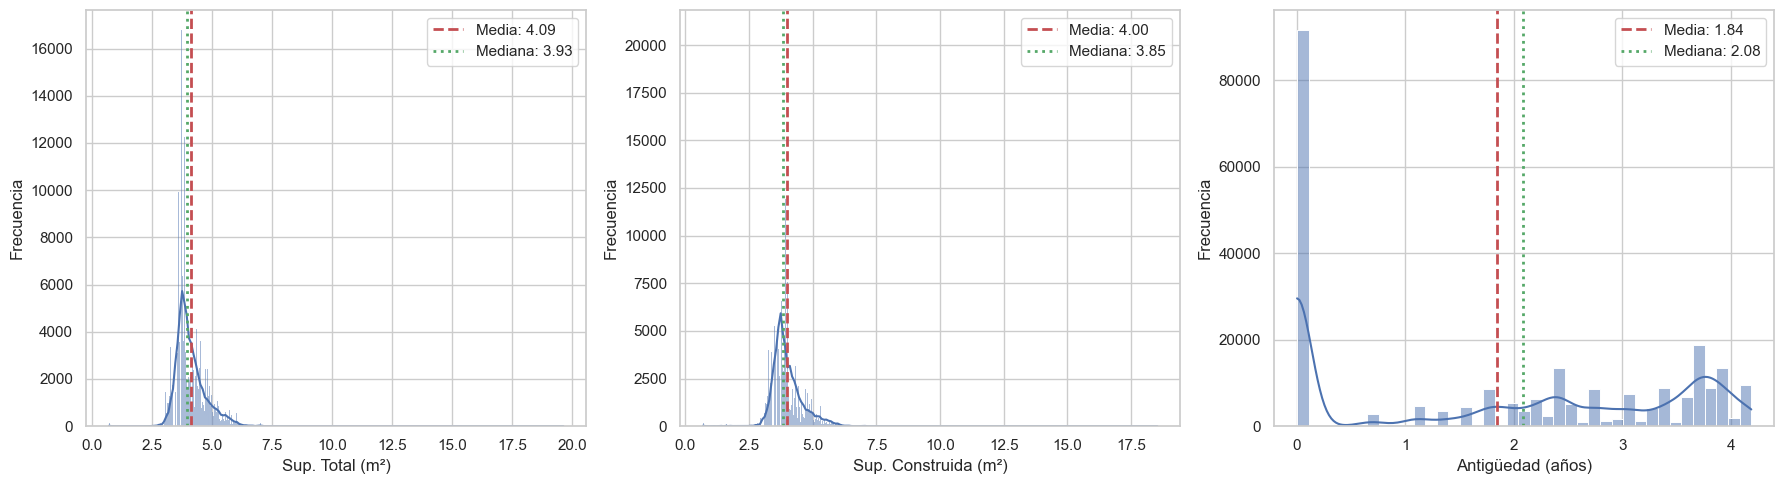

In [38]:
OUTLIER_COLS = [COLS.SUP_TOTAL, COLS.SUP_CONSTR, COLS.ANTIGUEDAD]
df_log = log_transform_features(df_capped, OUTLIER_COLS)
plot_histograms(df_log, OUTLIER_COLS)

La situación mejoró, pero siguen habiendo valores demasiado extremos que probablemente se correspondan a errores de medición (por ejemplo para superficie, hay valores demasiado grandes que podrían corresponderse con la superficie del edificio entero en lugar de la propiedad). Para Antiguedad, el valor máximo es alrededor de 500 años lo cual podría no ser un error. Entonces, cappeemos los outliers extremos en superficie

Capping outliers for columns: STotalM2, SConstrM2


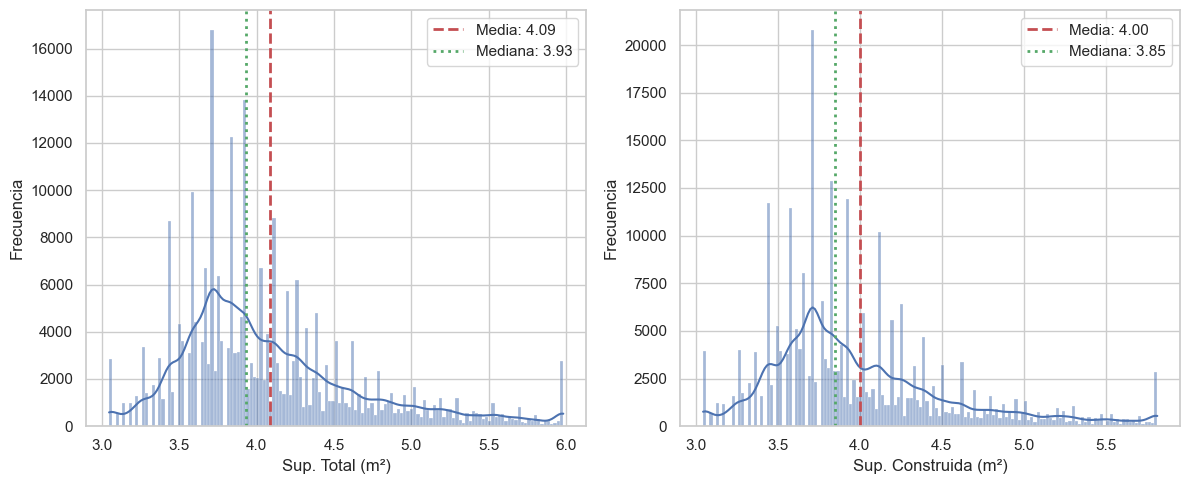

In [39]:
SUP_COLS = [COLS.SUP_TOTAL, COLS.SUP_CONSTR]
df_sup_capped, _ = cap_outliers(df_log, SUP_COLS, percentiles=(0.01, 0.99))
plot_histograms(df_sup_capped, SUP_COLS)

Ahora sí las distribuciones son más gaussianas lo cual va a ayudar a nuestros modelos. Finalmente, apliquemos una estandarización para que los datos se parezcan más a una normal estándar y tengan magnitudes similares:

Standardizing columns: id_grid, STotalM2, SConstrM2, Antiguedad, LONGITUDE, LATITUDE


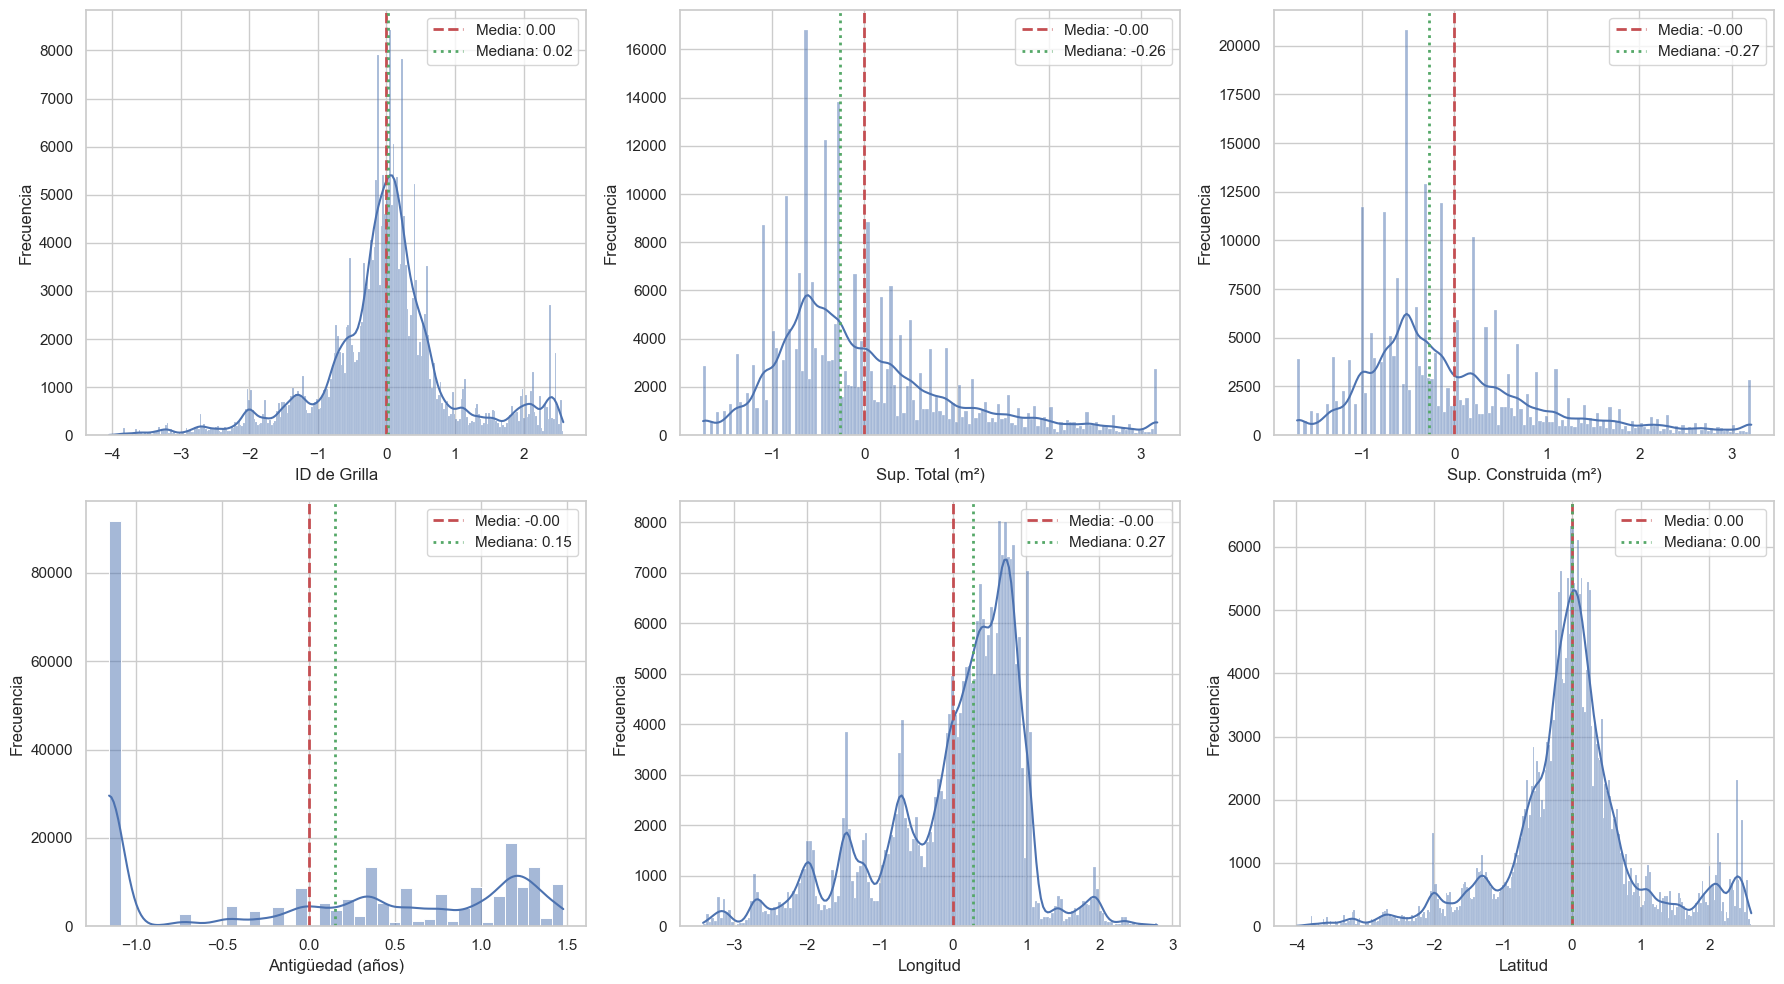

In [40]:
df_std, _ = standardize_features(df_sup_capped, NUMERICAL_FEATURES)
plot_histograms(df_std, NUMERICAL_FEATURES)

Comparamos el heatmap original versus el heatmap estandarizado:

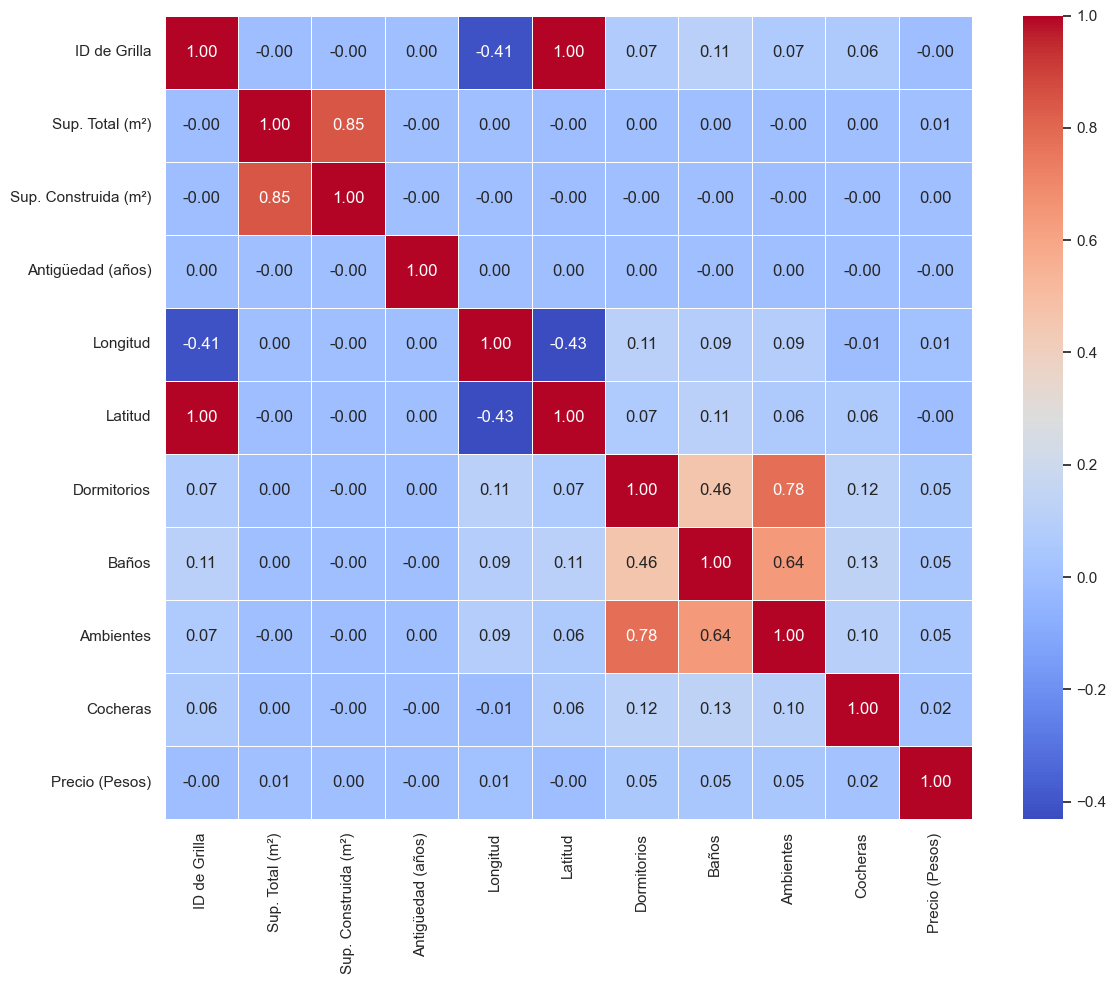

In [41]:
plot_correlation_heatmap(df, NUMERICAL_FEATURES + [COLS.DORMITORIOS, COLS.BANOS, COLS.AMBIENTES, COLS.COCHERAS, TARGET], filename="eda/04-correlation-matrix-original")

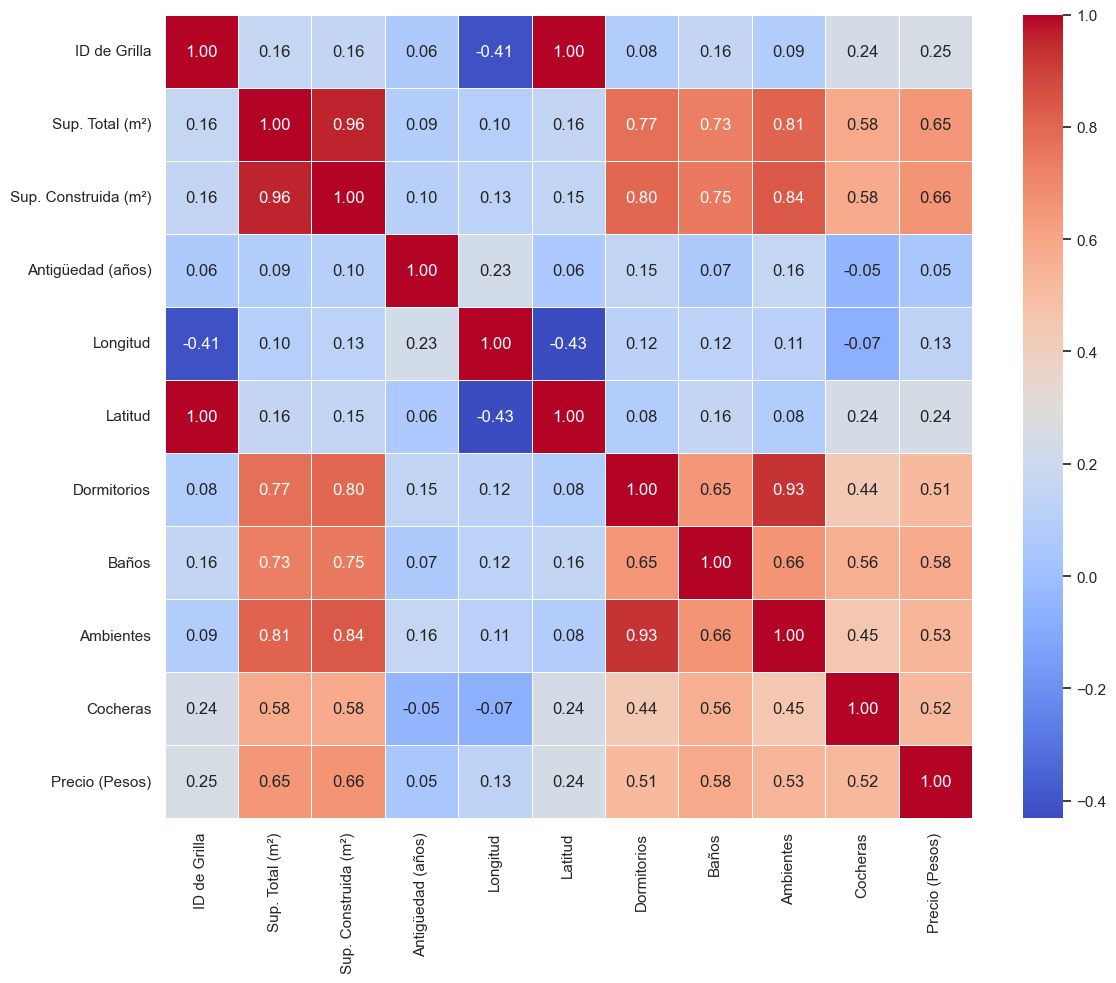

In [42]:
plot_correlation_heatmap(df_std, NUMERICAL_FEATURES + [COLS.DORMITORIOS, COLS.BANOS, COLS.AMBIENTES, COLS.COCHERAS, TARGET], filename="eda/04-correlation-matrix-std")

Ahora sí empiezan a aparece varias correlaciones! Muchas features empiezan a mostrar correlación alta con el precio, así como correlaciones entre sí. Las wque menos correlación tienen con el precio, interesantemente, son Antiguedad y las coordenadas (Latitud y Longitud)

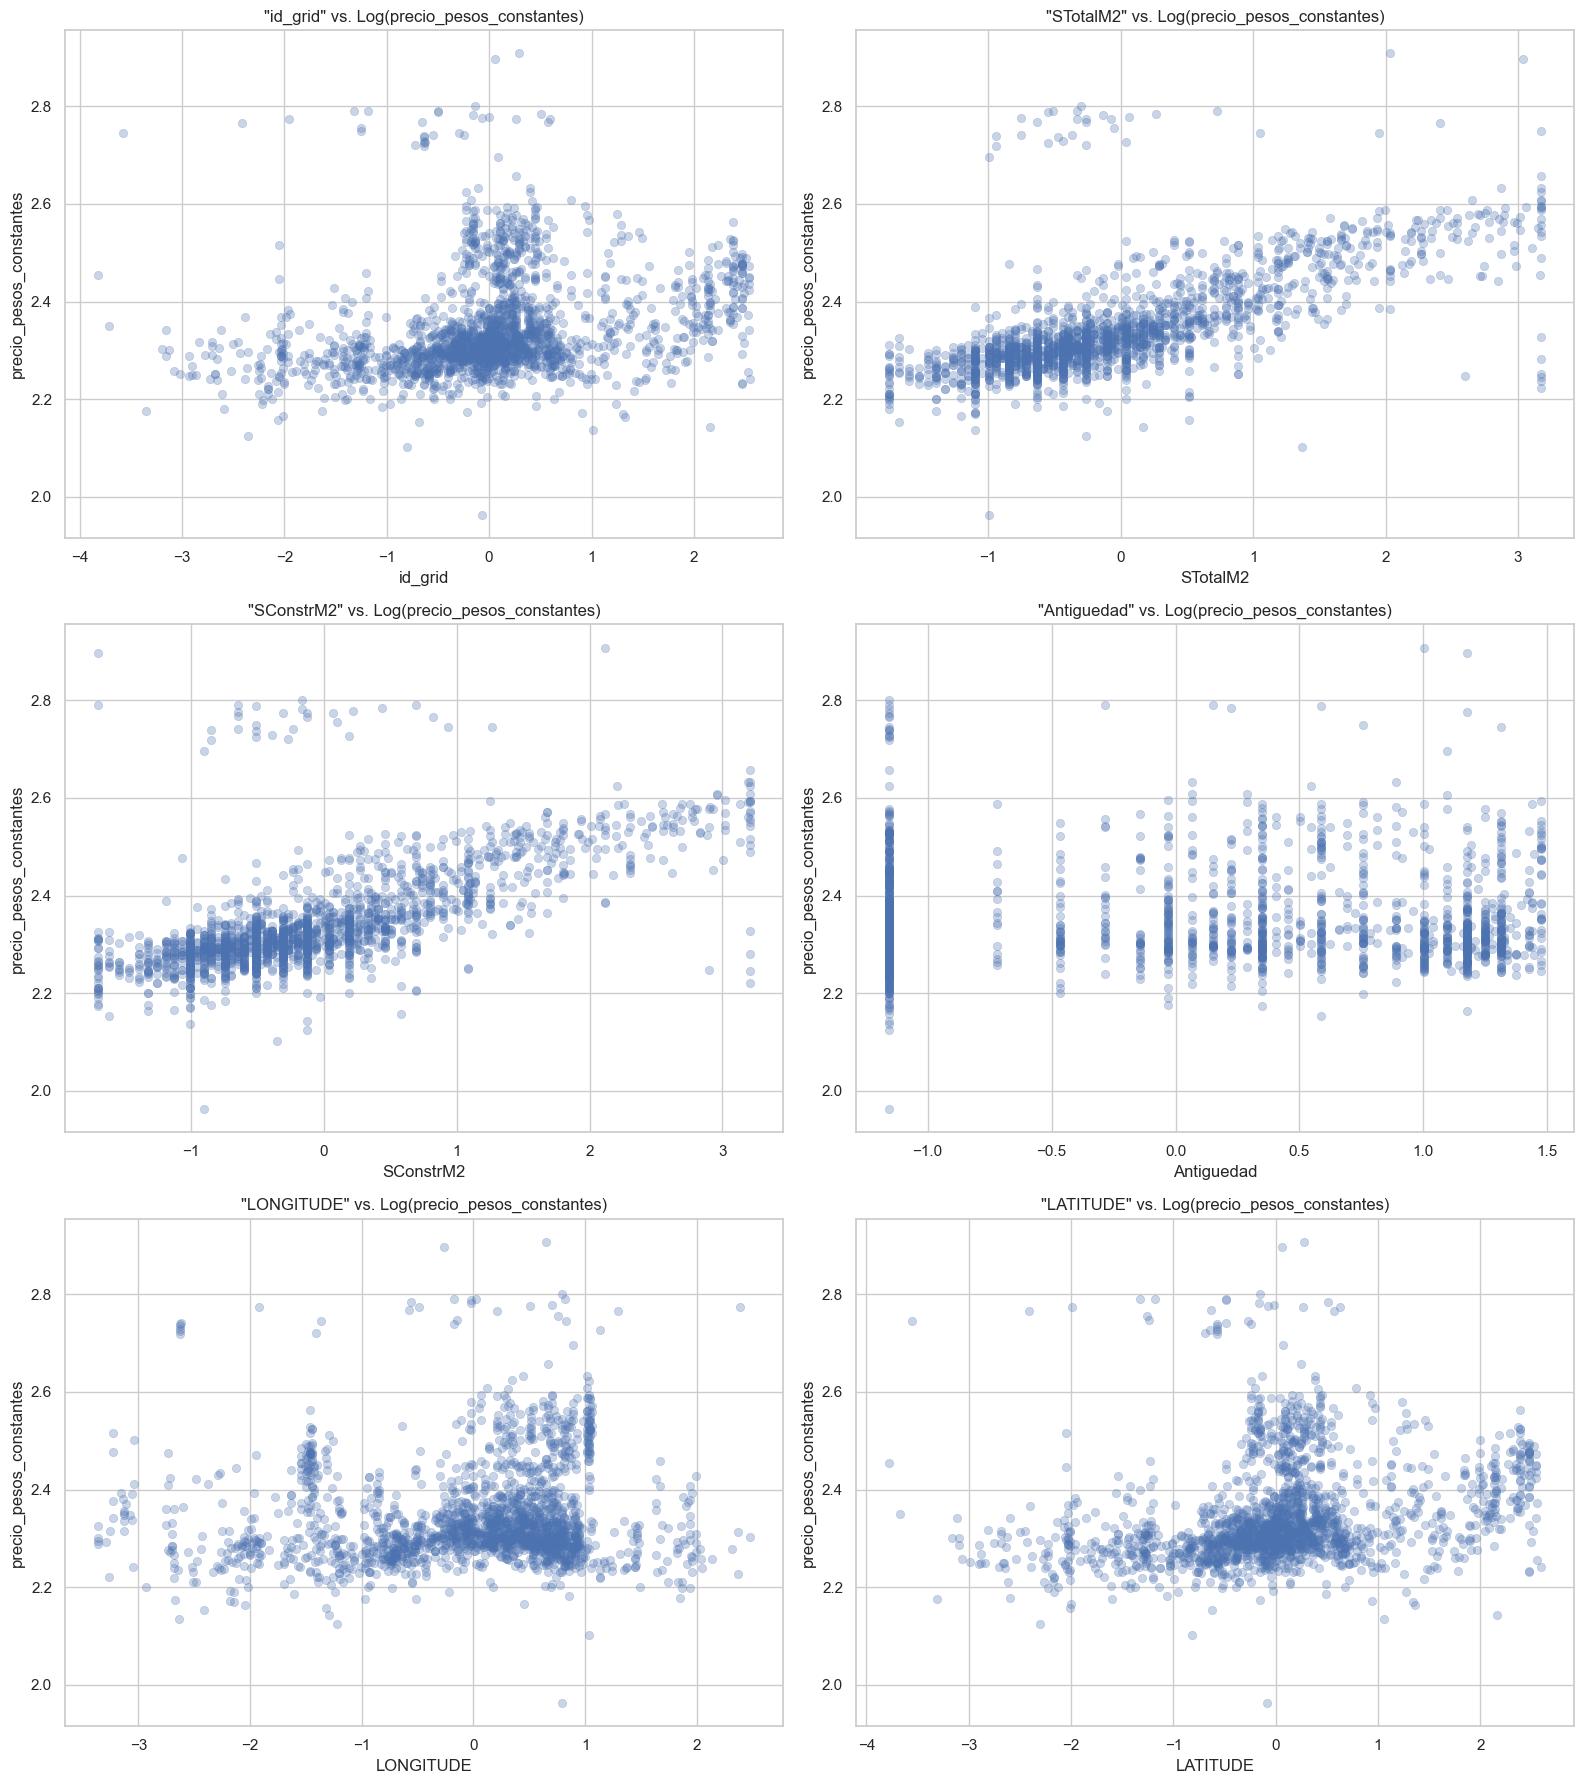

In [43]:
plot_numeric_vs_target(numeric_cols=NUMERICAL_FEATURES, target_col=TARGET, df=df_std)

En los scatter plots vemos cosas similares a la matriz de correlación:
- Las variables de superficie muestran cierta correlación lineal, siendo ambas variables muy parecidas. Podemos con seguridad eliminar alguna de las dos pues son redundantes
- Las variables de ubicación también muestran cierta correlación, con precios más altos cerca del cero. Lo mismo con id_grid. Podemos eliminar ésta última ya que es exactamente igual que latitud.

## Análisis de Features Categóricas

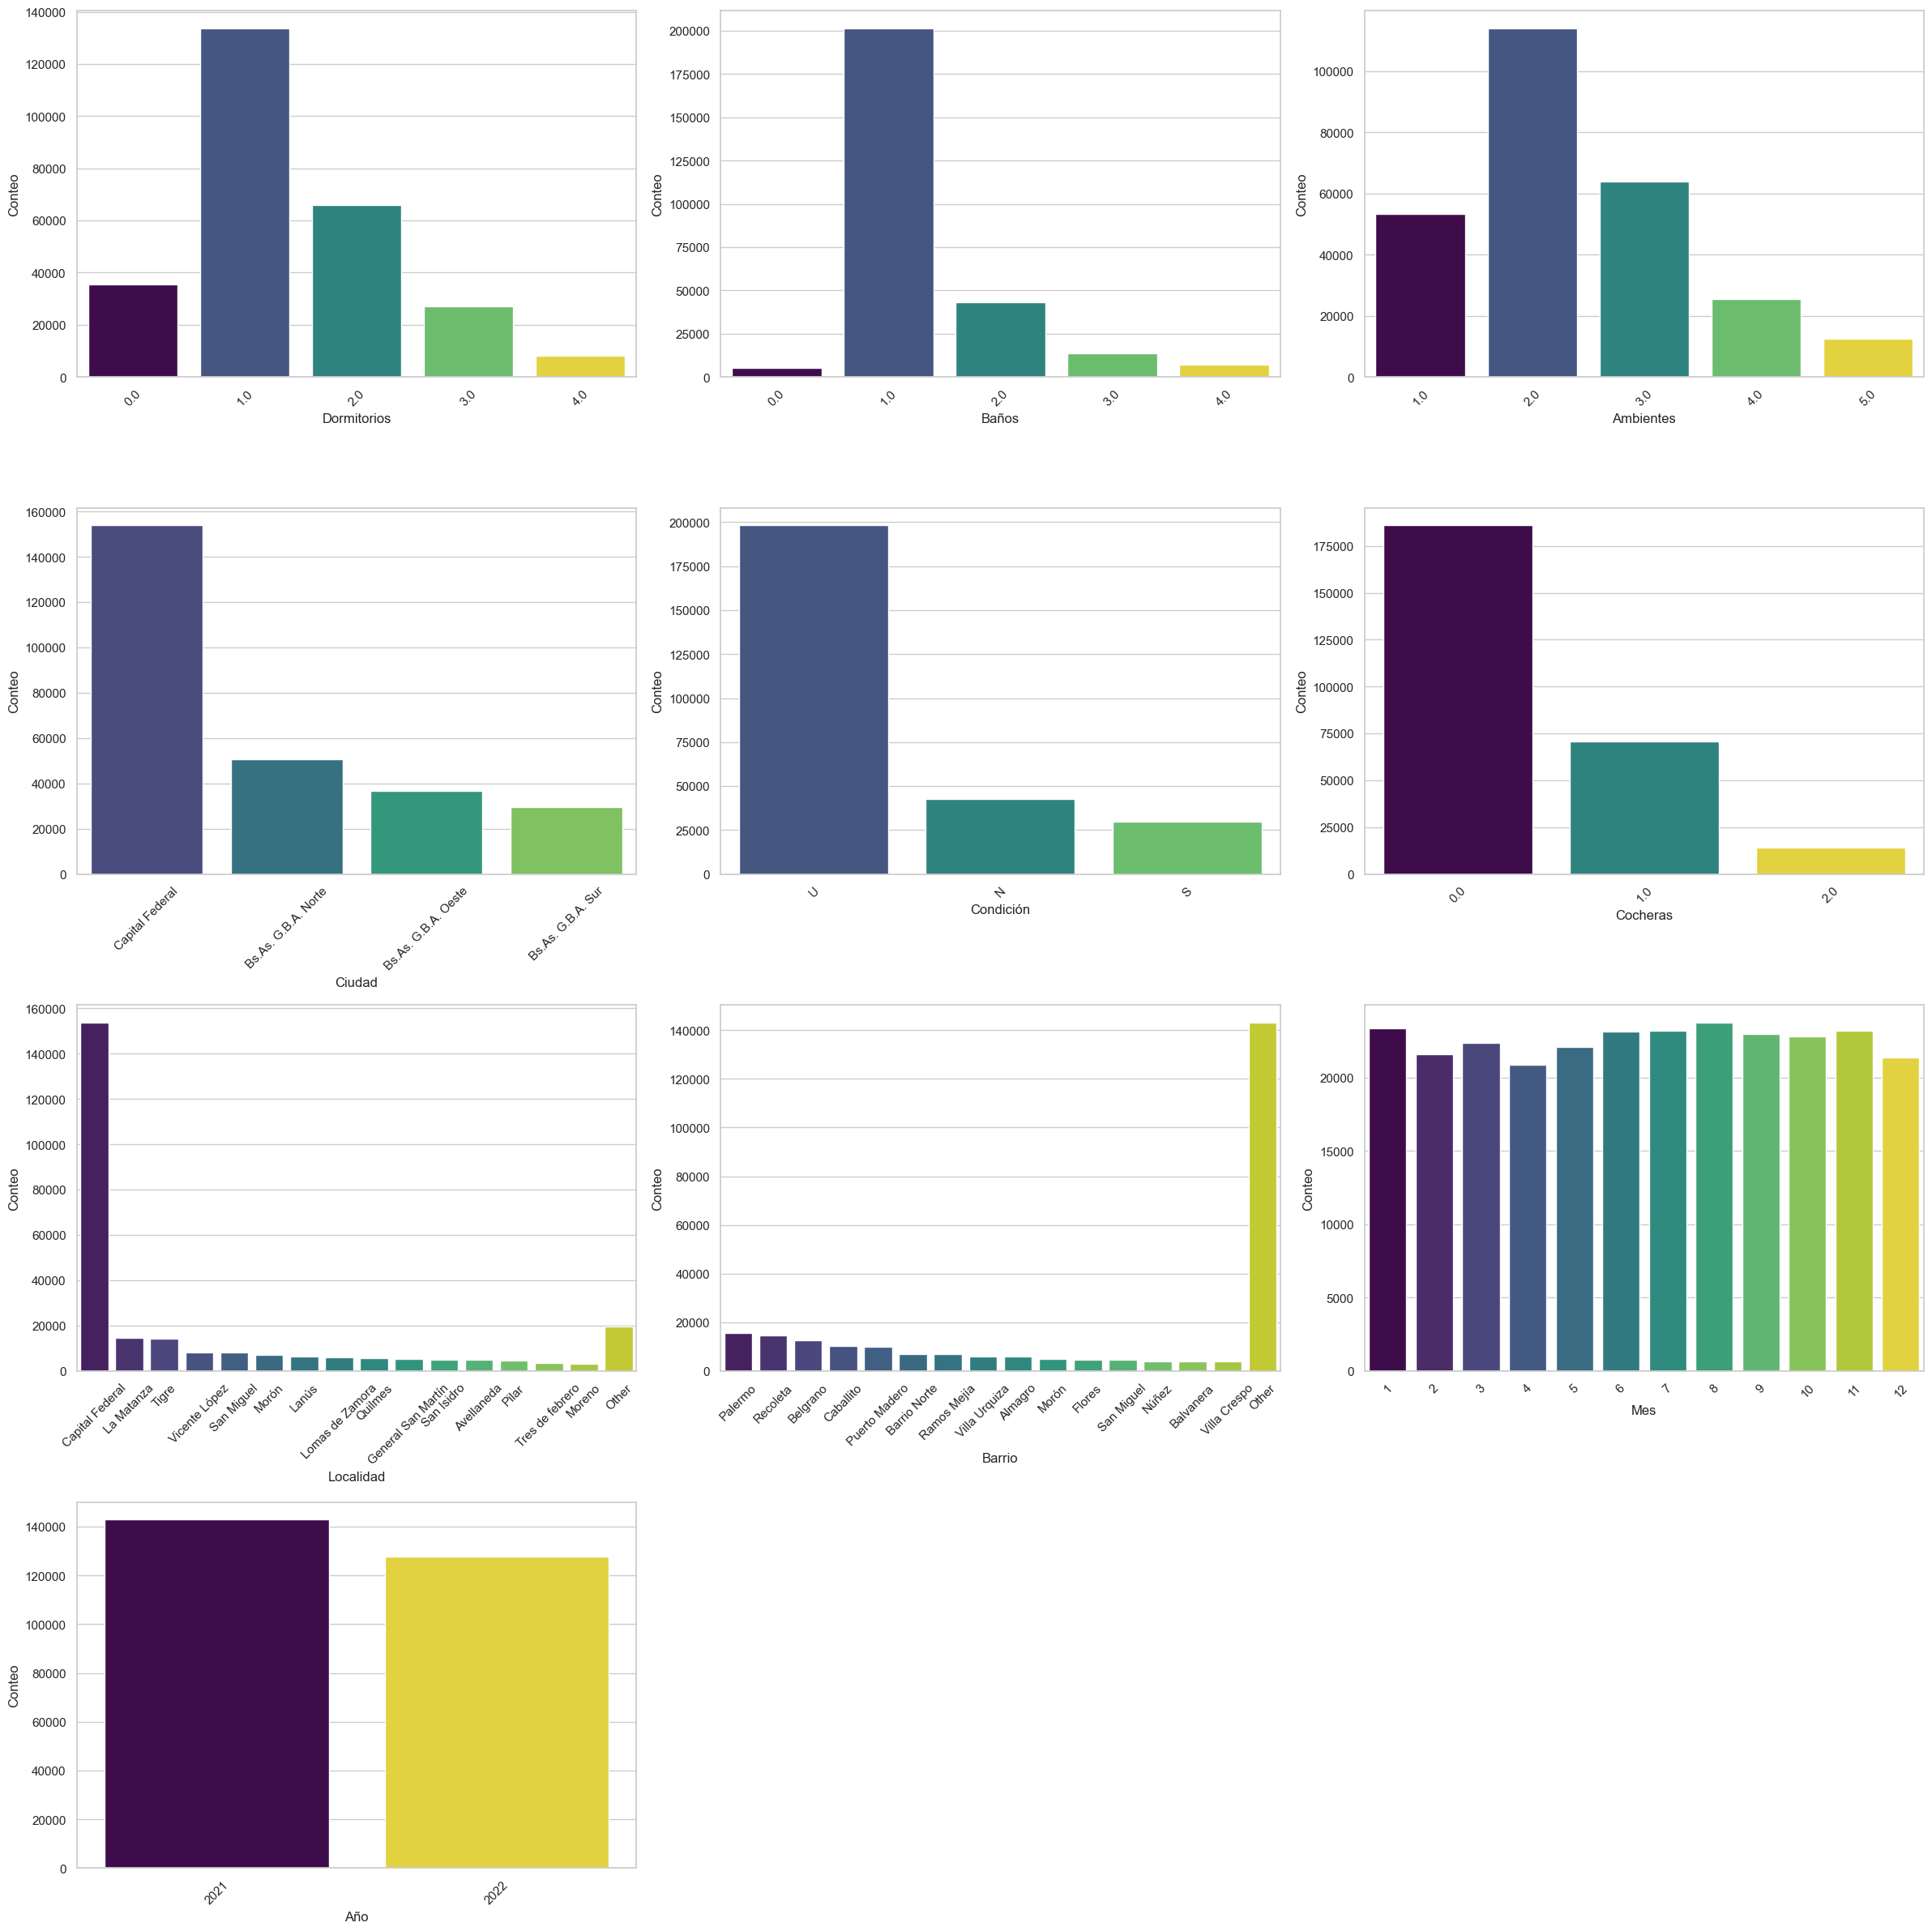

In [44]:
PURELY_CATEGORICAL_FEATURES = [COLS.DORMITORIOS, COLS.BANOS, COLS.AMBIENTES, COLS.PROVINCIA, COLS.CONDICION, COLS.COCHERAS, COLS.CIUDAD, COLS.BARRIO, COLS.MES, COLS.ANIO]
plot_bar_charts(df_std, PURELY_CATEGORICAL_FEATURES, n_cols=3, filename="eda/05-categorical-distribution")

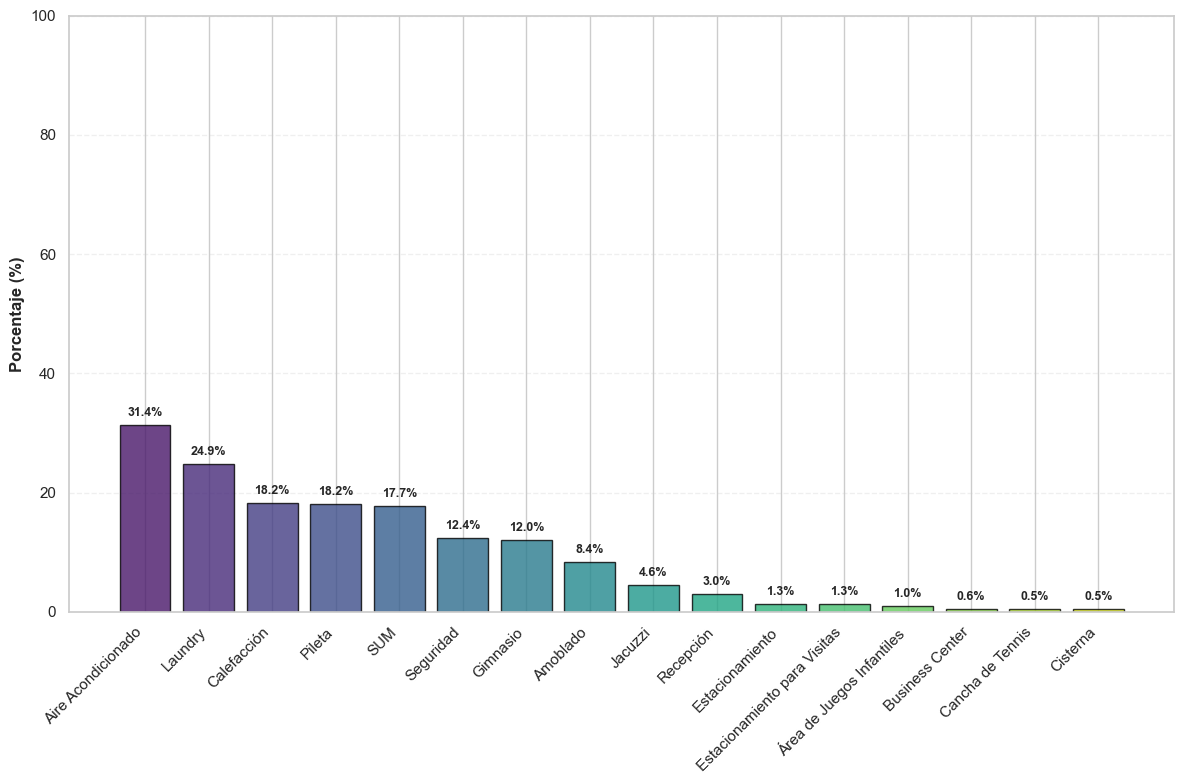

In [45]:
BOOLEAN_COLS = [COLS.AMOBLADO, COLS.BUSINESS, COLS.GIMNASIO, COLS.LAUNDRY, COLS.CALEFACCION, COLS.AIRE, COLS.RECEPCION, COLS.ESTACIONAMIENTO, COLS.JACUZZI, COLS.SEGURIDAD, COLS.PILETA, COLS.TENNIS, COLS.SUM, COLS.JUEGOS, COLS.CISTERNA,  COLS.ESTACIONAMIENTO_VISITAS]

plot_boolean_percentage(df, BOOLEAN_COLS, filename="eda/06-boolean-percentages")

Insights:
- Variables booleanas muy desbalanceadas. Especialmente algunas relacionadas con amenities de lujo, tienen un desbalance extremo, donde solo están presentes en algunas pocas propiedades.
- Otras variables categoricas como Ambientes y Dormitorios tienen una forma aproximadamente gaussiana. Probablemente no sean un problema.

Comparemos el impacto que tiene cada una de las features booleanas sobre el precio
- La métrica que se va a utilizar es la diferencia de medianas entre las muestras que son True y las muestras que son False. Cuanto más grande es la diferencia entre medianas, podemos decir que más grande es el impacto que tiene la feature sobre el precio

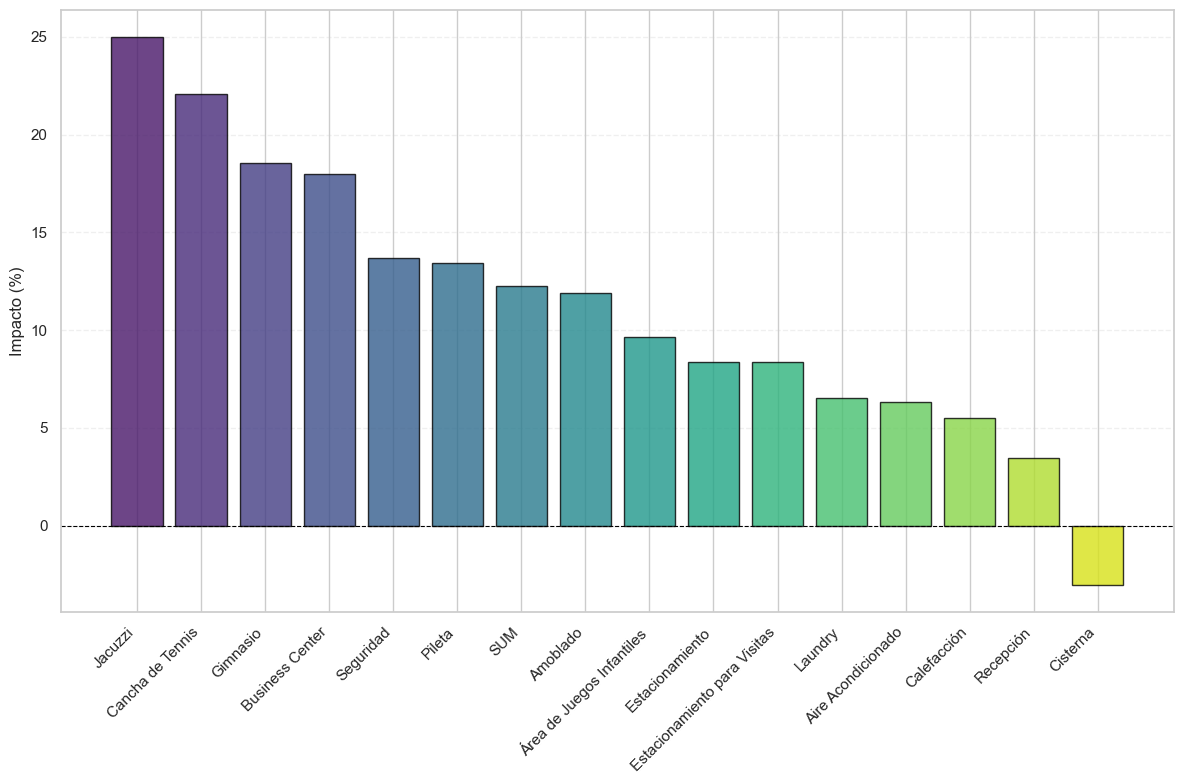

In [46]:
plot_median_price_impact(df_std, BOOLEAN_COLS, TARGET, filename="eda/07-boolean-impact")

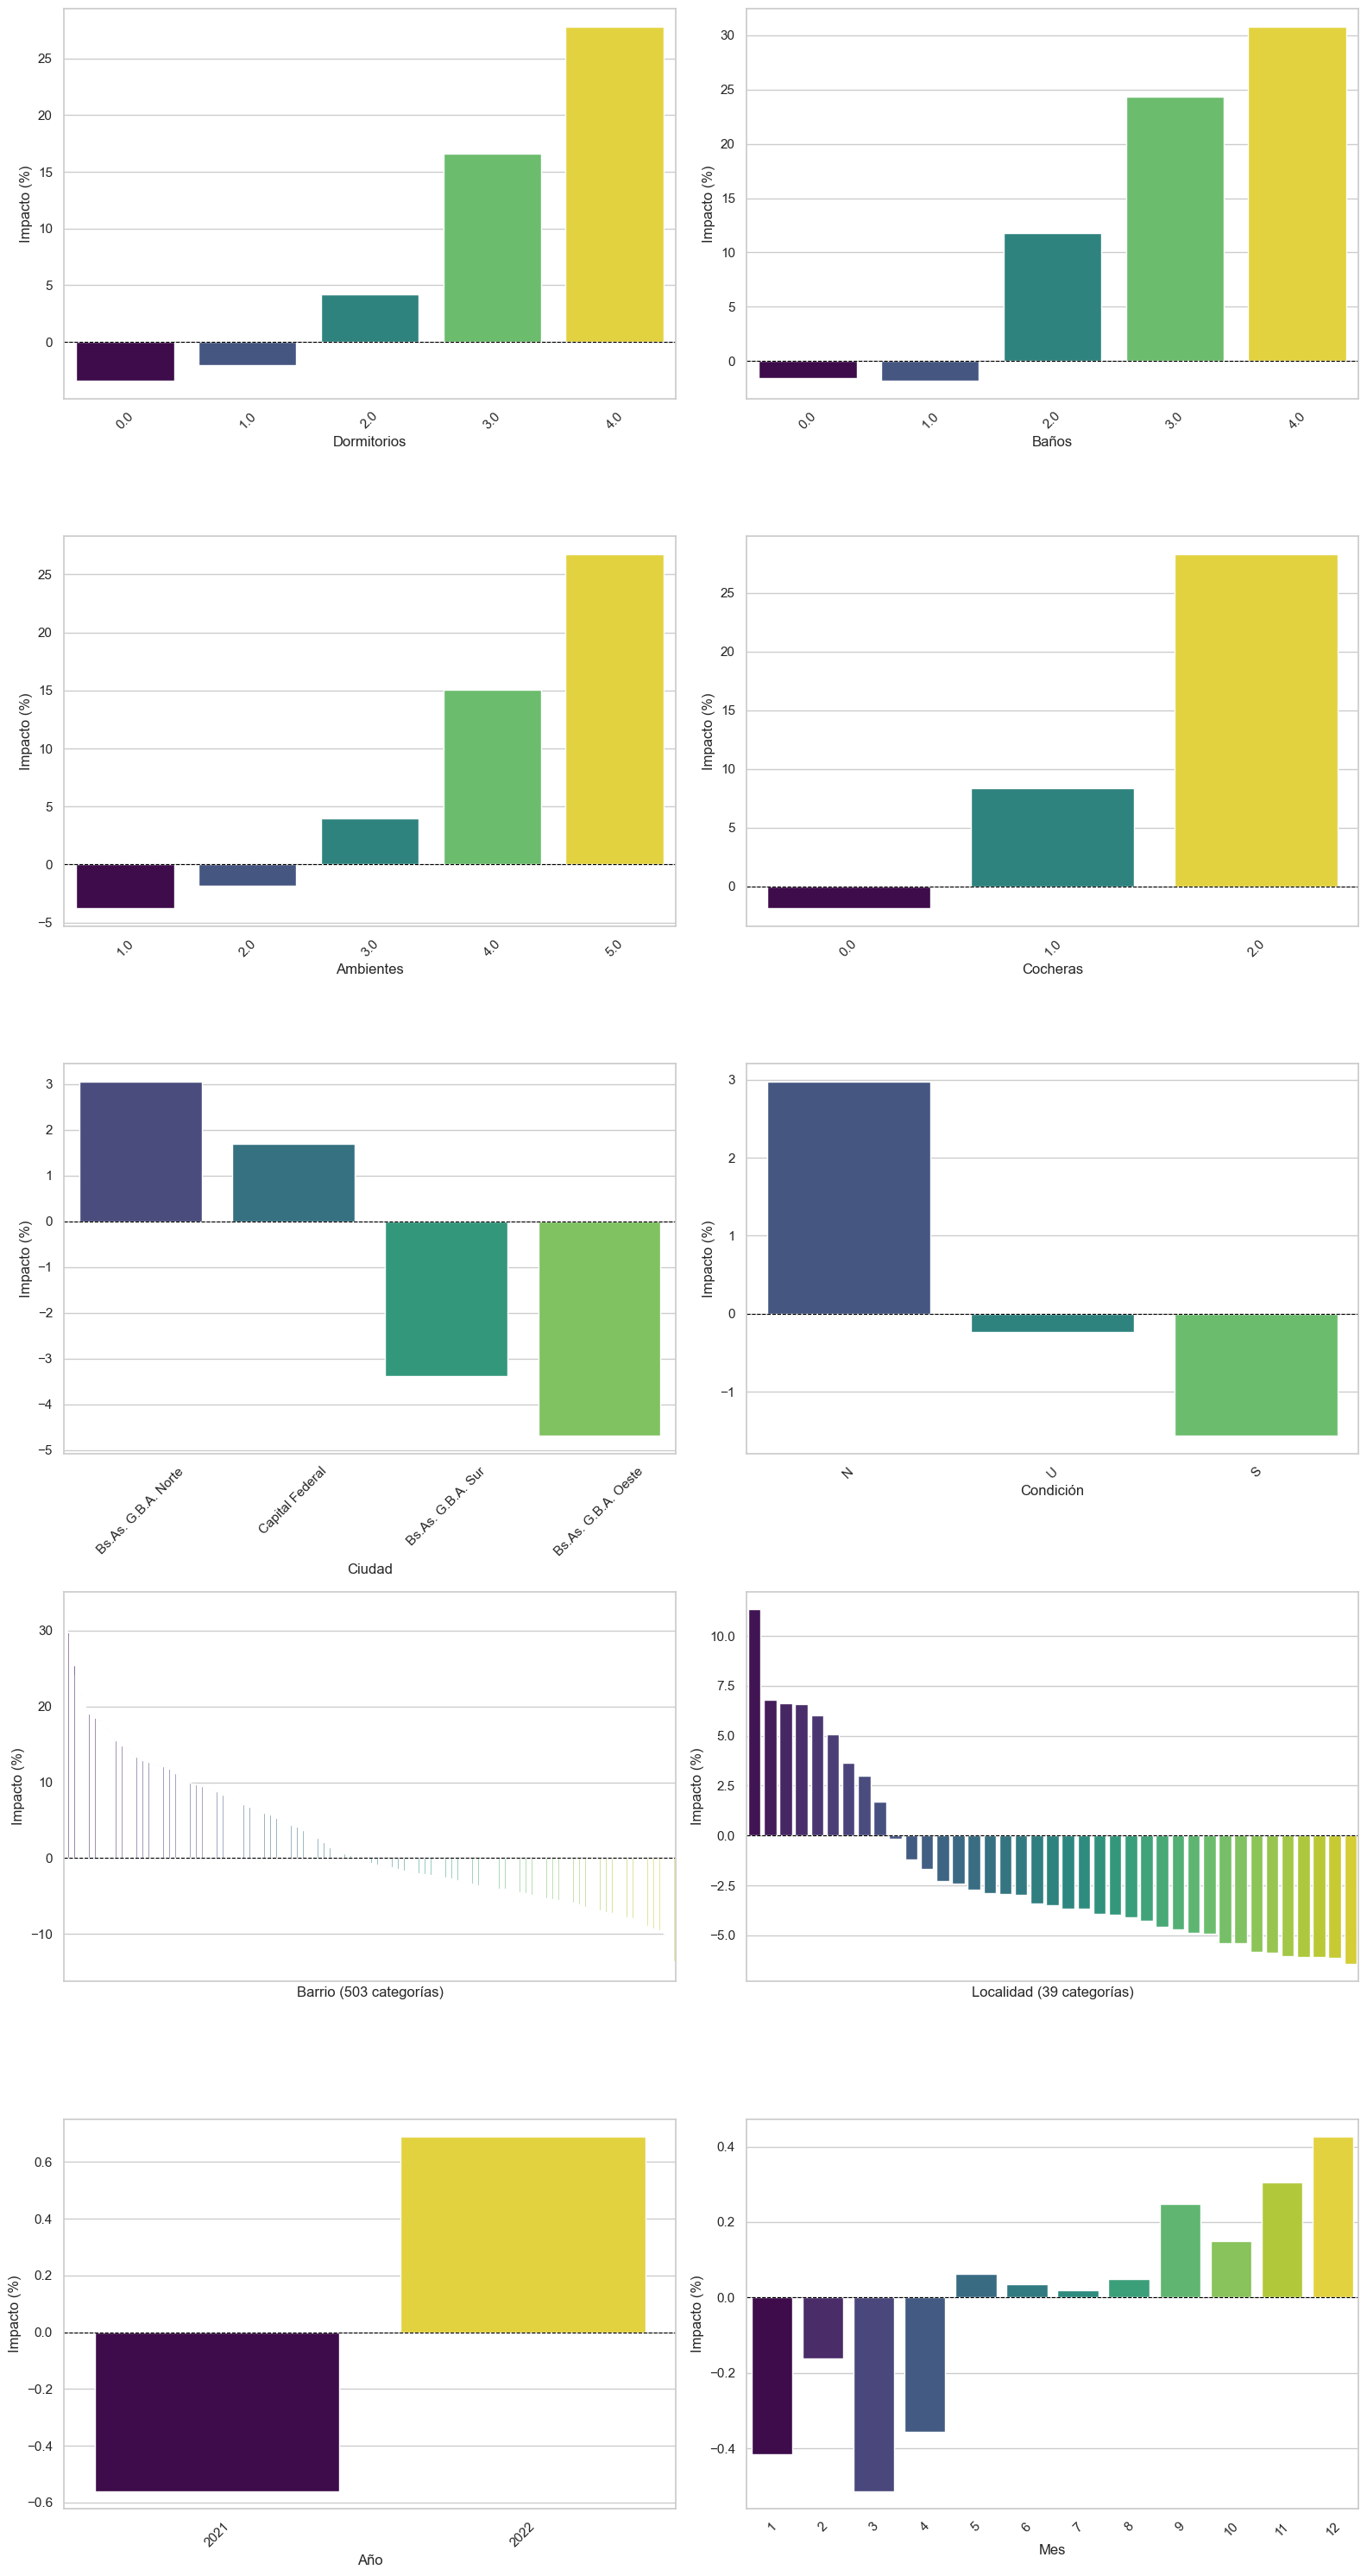

In [47]:
PURELY_CATEGORICAL_COLS=[COLS.DORMITORIOS, COLS.BANOS, COLS.AMBIENTES, COLS.COCHERAS, COLS.PROVINCIA, COLS.CONDICION, COLS.BARRIO, COLS.CIUDAD, COLS.ANIO, COLS.MES]
plot_categorical_impact(df_std, PURELY_CATEGORICAL_COLS, TARGET, filename="eda/09-categorical-impact")

Insights:
- Una mayor cantidad de dormitorios, baños, ambientes y cocheras tiende a subir el precio
- Las propiedades nuevas tienen en promedio un precio alrededor de 3% mayor que el promedio
- La categoría de zonas muestra claramente como las propiedades de Zona Norte son las más costosas, seguidas por CABA, Zona sur y Zona Oeste
- Los precios subieron en un pequeño porcentaje (en términos reales) de 2021 a 2022
- Ppareciera haber una muy leve correlacion entre el mes del año en el que se publicó la propiedad y el precio
- El barrio de la propiedad pareciera tener un impacto _muy_ alto en el precio

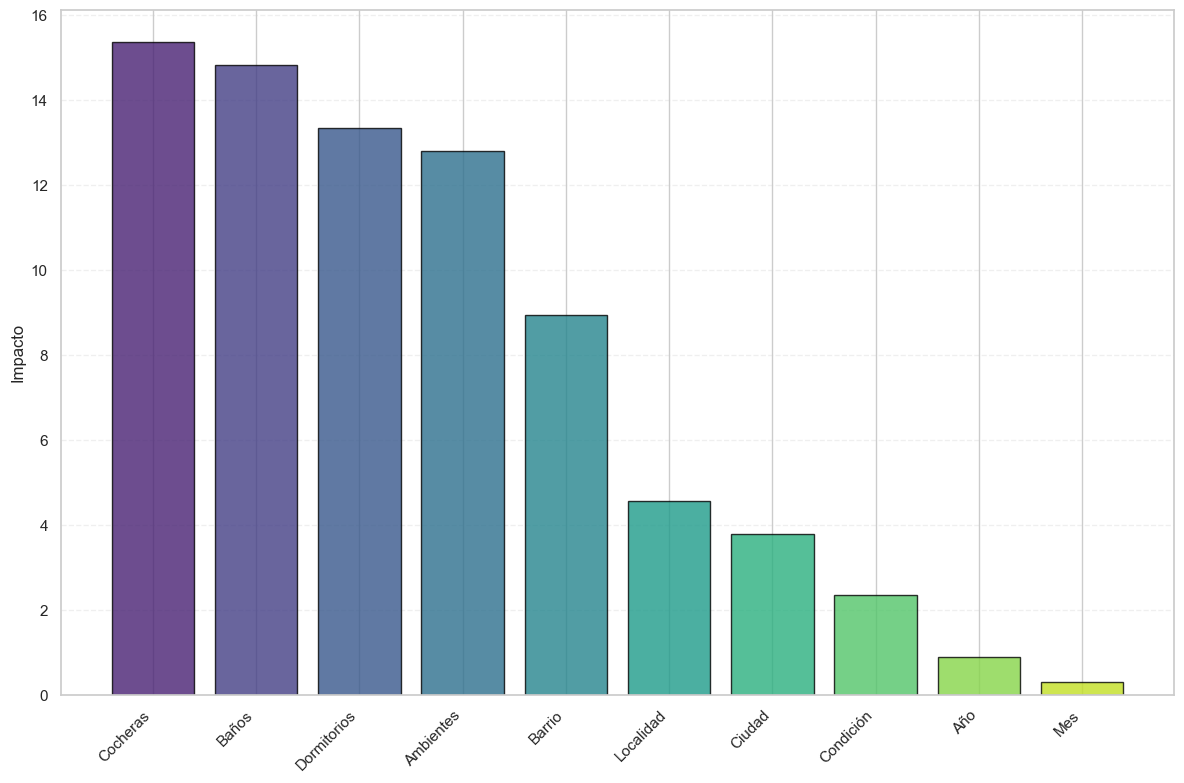

In [48]:
plot_feature_impact_ranking(df_std, PURELY_CATEGORICAL_COLS, TARGET, filename="eda/10-categorical-impact")

Este gráfico intenta comparar el efecto en el precio que tiene cada variable categórica. Para ello, se utiliza como métrica la desviación estandar del efecto sobre la media del precio de cada categoría, para cada columna.

Cocheras, baños, ambientes, dormitorios son las variables con el mayor impacto. Le siguen las variables relacionadas con la ubicación. Las relacionadas con la fecha de la publicación son las que menos impacto tienen.

## Análisis Geoespacial

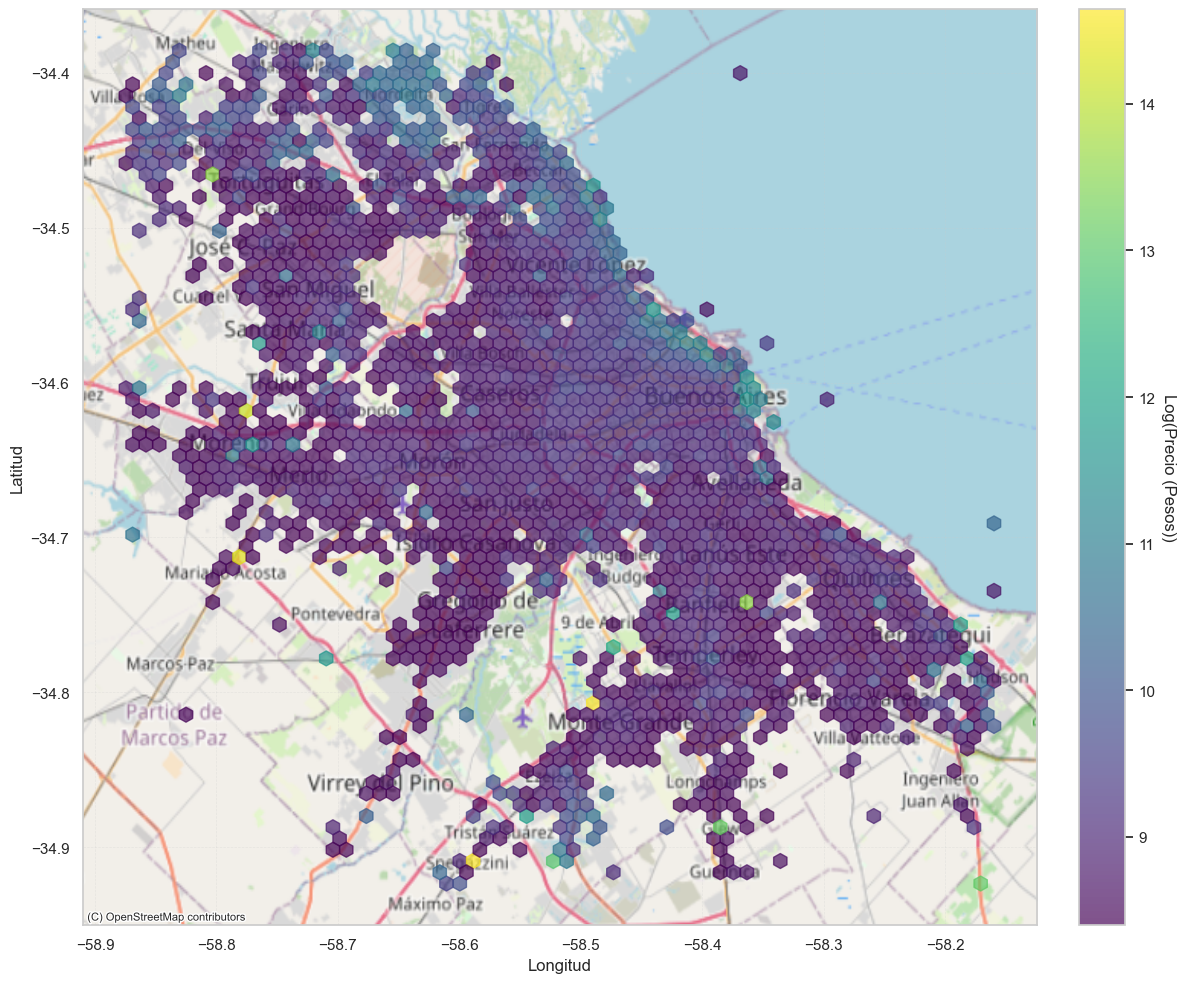

In [49]:
plot_geo_scatterplot(
    df,
    geo_cols=(COLS.LONGITUD, COLS.LATITUD),
    color_col=TARGET,
    log_scale=True,
    clip_percentiles=(0.05, 0.99),
    cmap='viridis',
    add_basemap=True,
    alpha=0.05,
    filename="eda/11-geo-plot"
)

En el gráfico se ve claramente como una angosta franja de la zona norte de la ciudad y del conurbano contiene a las propiedades con el mayor precio. Alejándose de esta franja, las propiedades bajan mucho de precio, a excepcion de algunas zonas aisladas del conurbano que probablemente se correspondan con barrios cerrados.

## Análisis de datos faltantes.

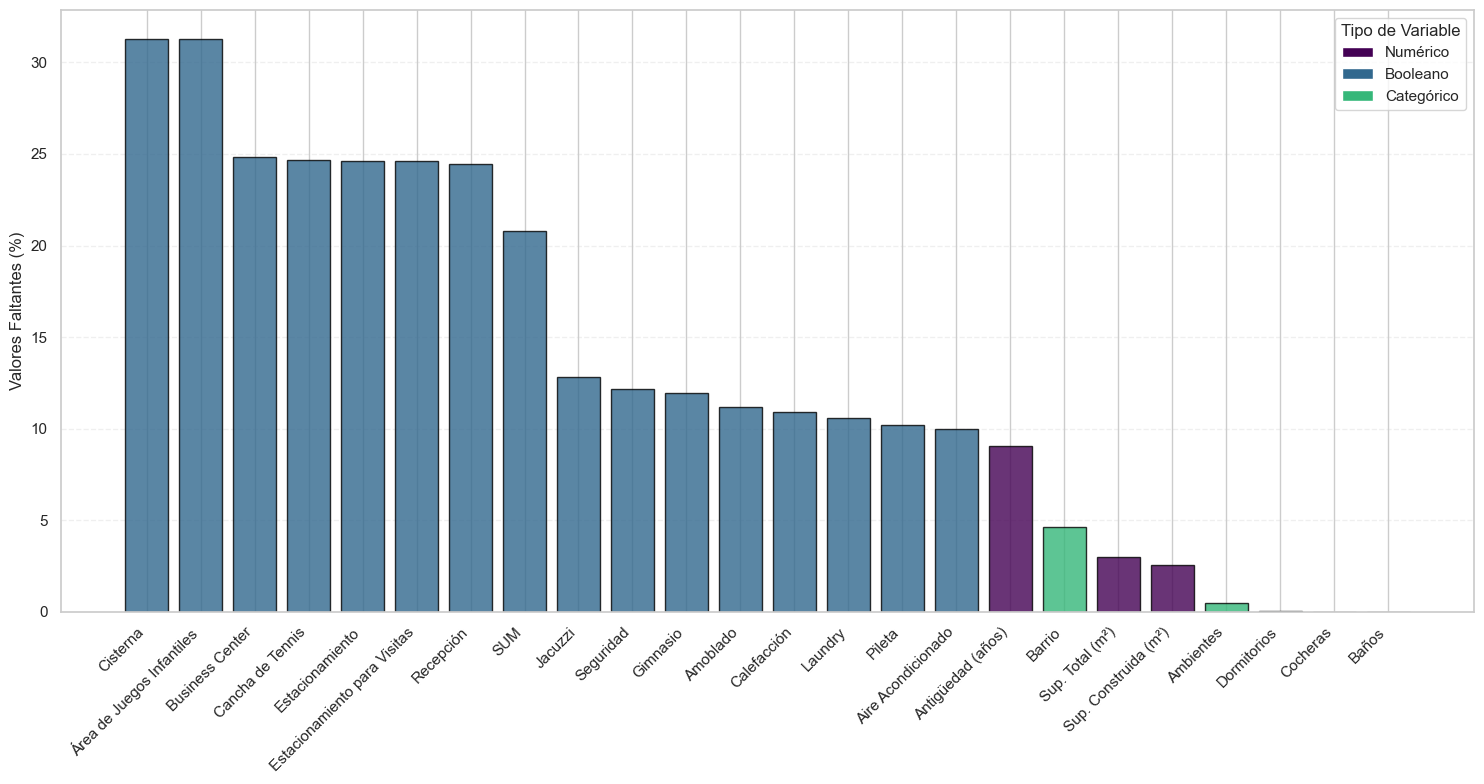


Info: The following 9 columns are not shown because they have no missing values:
id_grid, ITE_ADD_CITY_NAME, ITE_ADD_STATE_NAME, ITE_TIPO_PROD, LONGITUDE, LATITUDE, precio_pesos_constantes, year, mes_listing


In [50]:
plot_missing_values(df_std, numeric_cols=NUMERICAL_FEATURES, bool_cols=BOOLEAN_COLS, cat_cols=PURELY_CATEGORICAL_COLS)

Las features con menos NaNs son Baños, Cocheras, Domritorios y Ambientes, que a la vez son las features que más impacto tienen en el precio. Al ser tan pocas muestras las que tienen estos datos faltantes, y al ser tan importantes estos datos, lo mejor será directamente descartar estas filas.



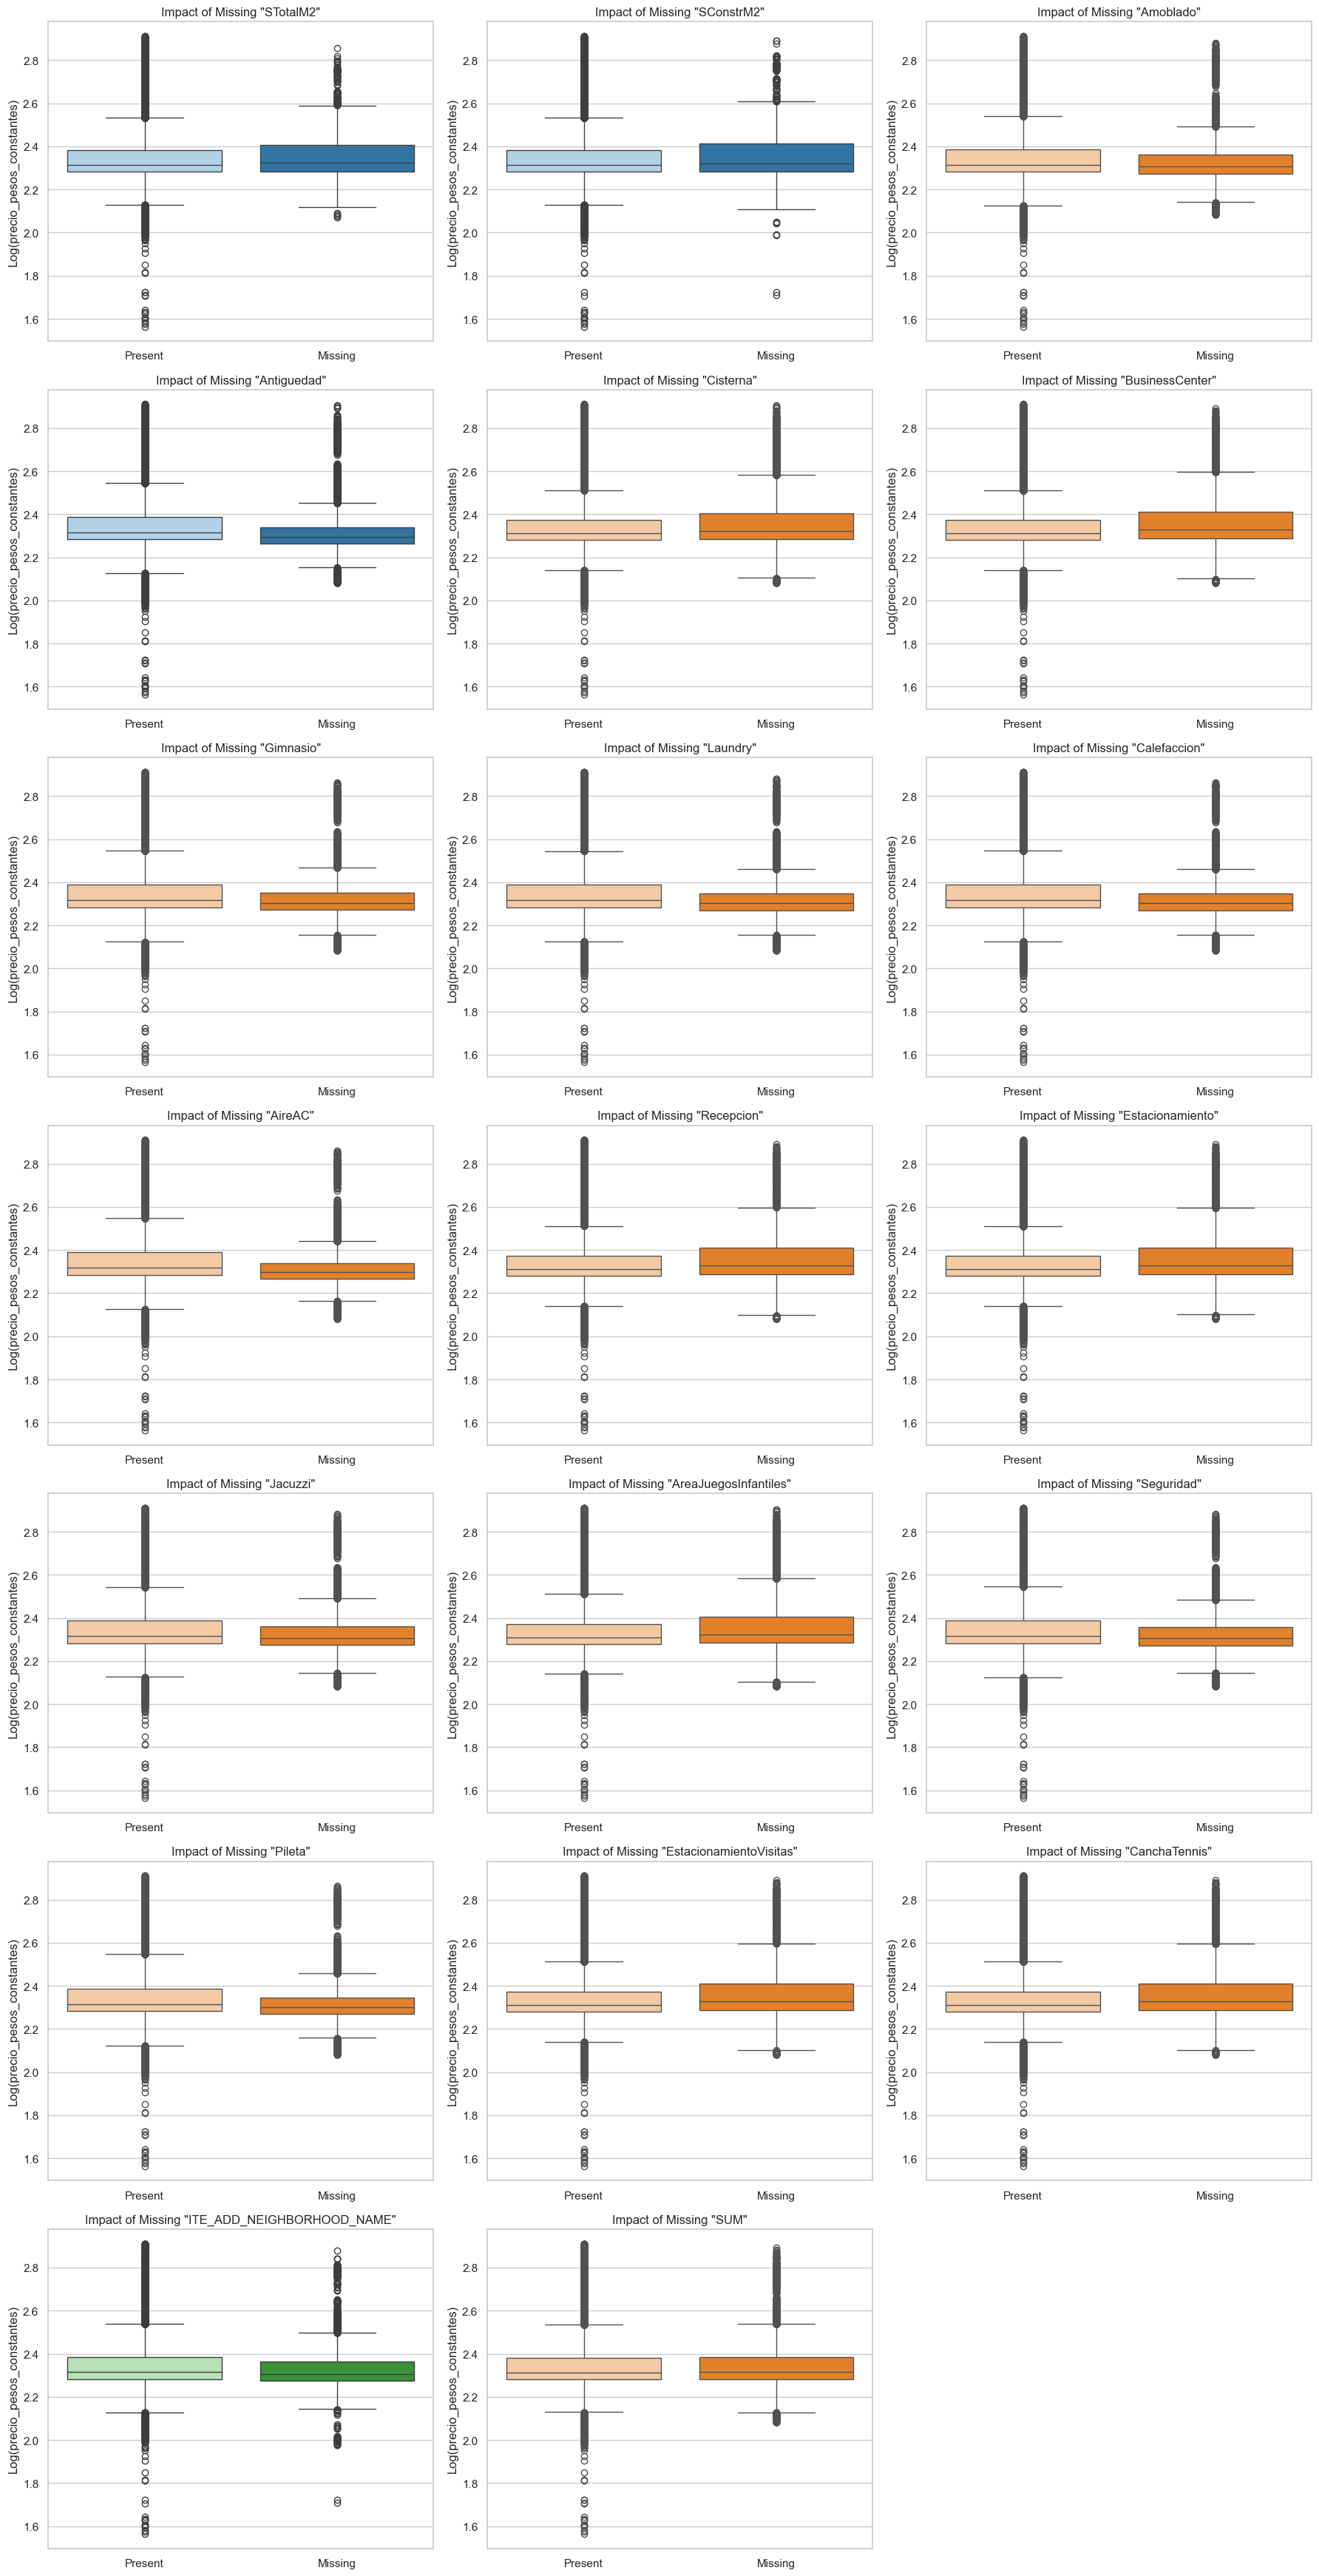

In [51]:
plot_missing_data_impact(df_std, numeric_cols=NUMERICAL_FEATURES, bool_cols=BOOLEAN_COLS, cat_cols=[COLS.BARRIO], target_col=TARGET, exclude_cols=[COLS.BANOS, COLS.COCHERAS, COLS.DORMITORIOS, COLS.AMBIENTES])

Las variables booleanas son las más problemáticas, con un gran porcentaje de datos faltantes que no podemos simplemente descartar. Lo mismo con las variables de superficie y de edad.

En cuanto al barrio, también hay una buena cantidad de datos faltantes, y esta feature es muy importante. Sin embargo, al ser demasiado grande la cantidad de barrios que hay, lo más probable es que no hagamos one hot encoding, ya que tendríamos una cantidad gigante de features solo para esta variable (más de 500). Lo que podríamos hacer es, por ejemplo, inputar con el precio medio del barrio, o algo similar. En este caso, será sencillo inputar los datos faltantes por ejemplo inputando por la media total del precio del dataset, o del precio de la ciudad por ejemplo.

En cuanto a las distribuciones del precio, esta es casi idéntica para los datos presentes y los faltantes, para las variables que fueron graficadas. La única diferencia que se ve en todos los casos es que la distribución del precio para los datos presentes tiene más outliers hacia abajo de la mediana que los datos ausentes.

Como las distribuciones son lago diferentes, sobre todo en los outliers, podríamos considerar, para las variables que fueron inputadas, agregar una nueva columna booleana que indique si esa variable fue inputada o no.

SUM tiene una cantidad enorme de datos faltantes y su impacto en el precio no es demasiado significativo, la podemos eliminar.

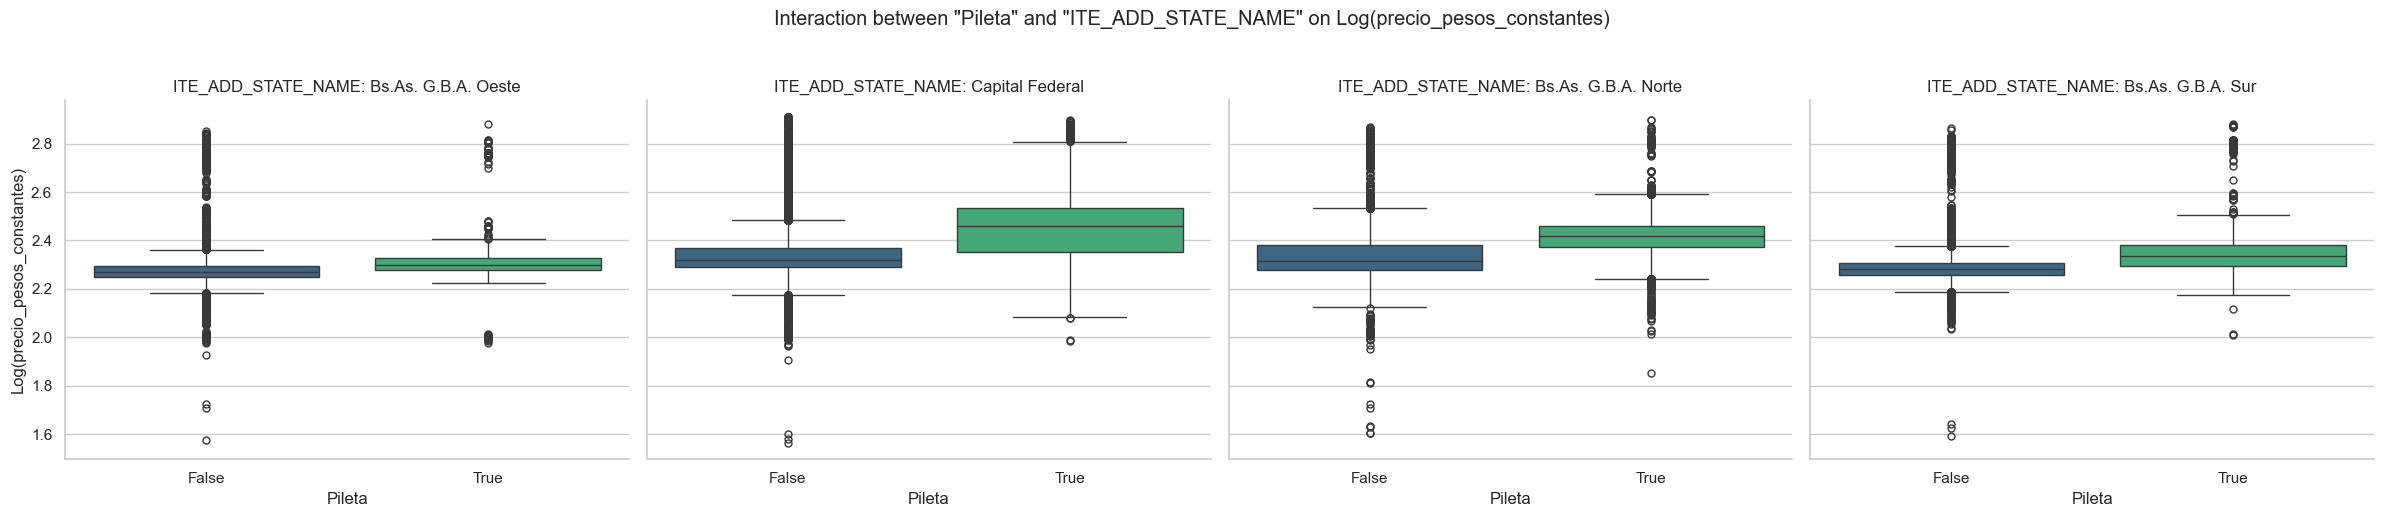

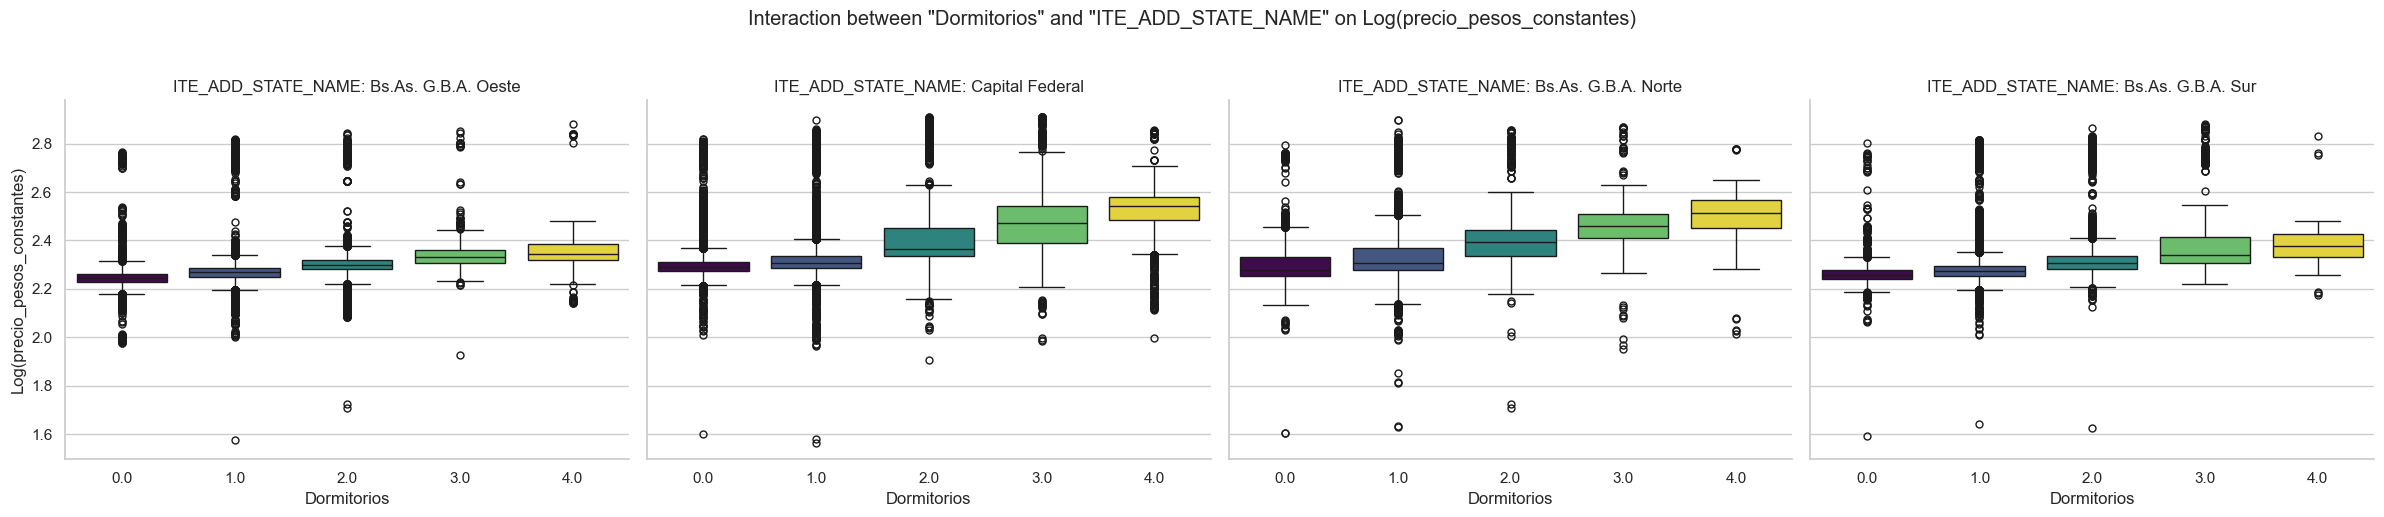

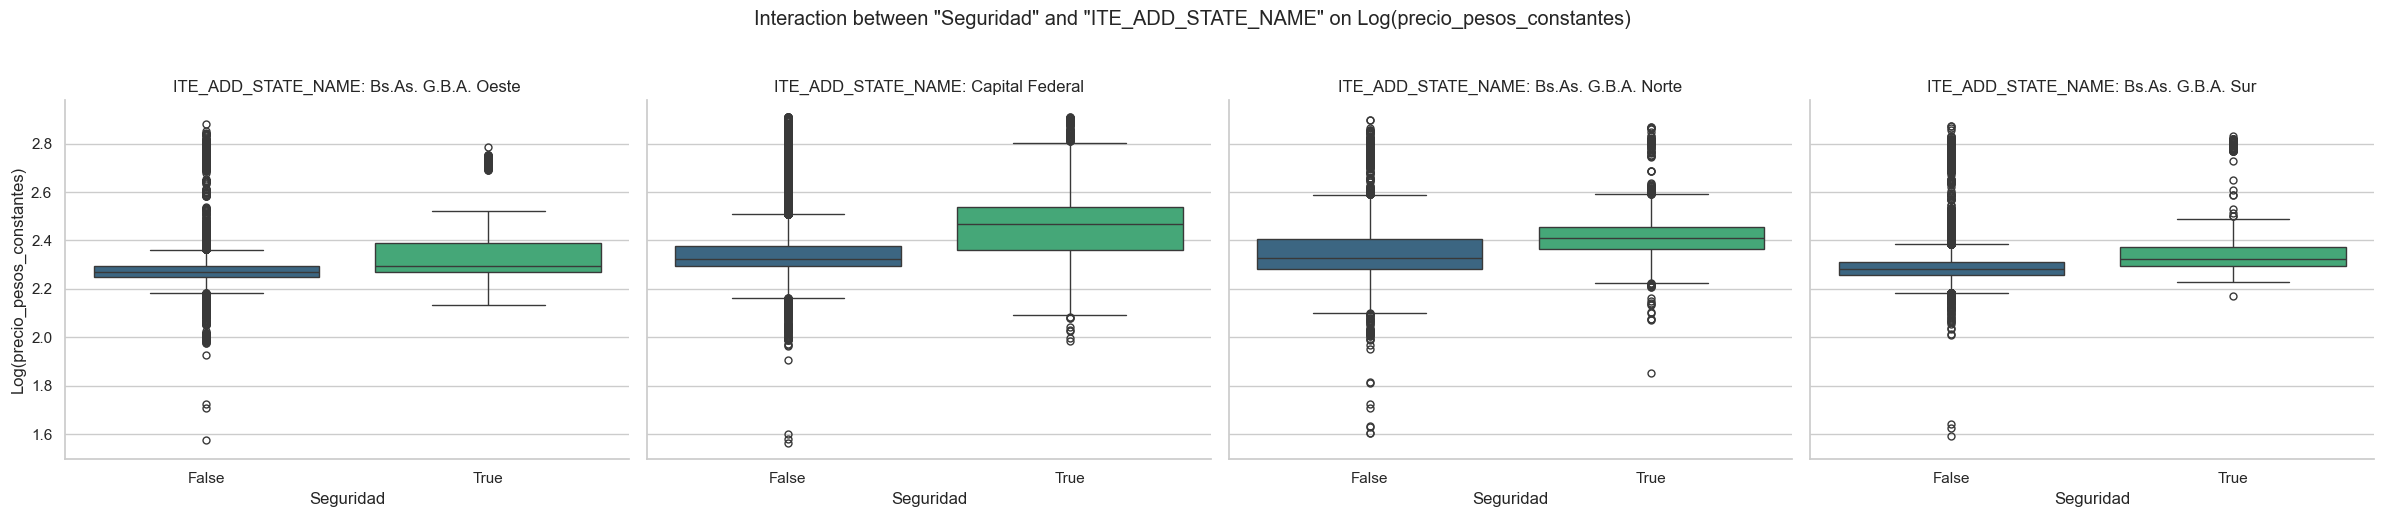

In [52]:
plot_interaction(
    df=df_std,
    target_col=COLS.TARGET,
    x_cols=[COLS.PILETA, COLS.DORMITORIOS, COLS.SEGURIDAD],
    facet_col=COLS.PROVINCIA
)

La mayoría de las features parecen tener un impacto distinto sobre el precio dependiendo de la zona. Para las 4 features probadas, todas tienen el impacto más grande en el precio si están en Capital, seguidas por Zona Norte.

# Conclusiones & Preprocesamiento

## Descubrimientos

### Precio
El target, precio_pesos_constantes, está extremadamente sesgado, con la gran mayoría de propiedades concentrándose en un rango de precios bajo, con una angosta cola de propiedades de muy alto valor. Una transformación logarítmica normaliza esta distribución, lo cual es más adecuado y útil para la mayoría de modelos. Los modelos, entonces, van a predecir el logaritmo del precio.

También se encontraron propiedades con precios extremadamente altos, que serán tratados mediante un clippeo en el percentil 0.98 para mitigar su efecto

### Variables numéricas
Al igual que con el precio, variables numéricas como STotalM2 y Antiguedad presentaron mucha asimetría. Clipear outliers y aplicar transformación logarítmica ayudó.

Hay otras variables numéricas como Dormitorios, Banos, Ambientes y Cocheras que también presentaban outliers extremadamente altos, imposibles para cualquier propiedad. Al clipear los outliers, estas variables se convirtieron en categóricas, con solo algunos valores únicos.

Finalmente, se detecto una muy alta correlación entre STotalM2 y SConstrM2 lo cual justifica eliminar una de ellas. Lo mismo con id_grid y LONGITUD.

### Análisis de impacto
El análisis de impacto reveló que las features relacionadas con la ubicación y las caracterísitcas principales de la propiedad (baños, dormitorios, etc) son las que tienen mayor impacto en el precio. Otras, como las relacionadas con la fecha de publicación, son las de menos impacto.

### Análisis de interacción con la ciudad
El análisis de interacción reveló que algunas features tienen más impacto si se encuentran en Capital Federal o Zona Norte que en otras zonas del AMBA.

### Patrón en datos faltantes
Las amenities booleanas son las más incompletas. En la mayoría de features, si bien la mediana del precio no varía significativamente entre datos presentes y faltantes, la distribución de outliers sí que lo hace. Esto nos indica que la falta de un dato no es _completamente_ aleatoria.


## Plan de preprocesamiento
En base a los descubrimientos mencionados, se propone el siguiente plan de preprocesamiento.

Este pipeline va a ser tuneado para cada modelo dependiendo de qué efecto tiene cada transformación sobre la performance de los modelos

### Datos faltantes


- [x] Eliminar columnas:
    - id_grid: es exactamente igual a LATITUDE
    - STotalM2: correlación demasiado alta con SConstrM2


- [x] Agregar columnas:
    - Agregar columna SDescubiertaM2 = STotalM2 - SConstrM2


- [x] Imputar con False los datos faltantes en columnas booleanas
    - Amoblado, Gimnasio, Laundry, Calefaccion, AireAC, Seguridad, Pileta


- [x] Imputar con la mediana los datos faltantes en columnas numéricas
    - SConstrM2, SDescubiertaM2, Antiguedad

- [x] Imputar con la moda: Ambientes, Dormitorios, Cocheras, Banos


- [x] Para columnas imputadas, agregar columna que indique si el dato fue imputado o no.
    - Esto es debido a la diferencia en las distribuciones que encontramos para las muestras con datos faltantes
    - Para las columnas imputadas con la moda no hace falta esto, ya que son muy pocos los datos faltantes y vamos a agregar muchas columnas innecesariamente.


### Outliers
- [x] Clippear percentil 0.98:
    - SConstrM2, SDescubiertaM2, Antiguedad, Dormitorios, Banos, Ambientes, Cocheras, Precio

### Log transform
- [x] Transformación
    - Logarítmica SConstrM2, SDescubiertaM2, Antiguedad, Precio

### Estandarización
- [x] Estandarizar: SConstrM2, SDescubiertaM2, Antiguedad

### One-hot encoding
- [x] One-hot encoding de ITE_ADD_STATE_NAME, ITE_ADD_TIPO_PROD, year



Todo esto fue implementado en `src/pipeline.py`. Probemos cómo funciona:

# División del dataset: propiedades normales vs. propiedades lujosas
Se descubrió que el dataset tiene propiedades _extremadamente_ caras. Tras experimentación con modelos en notebooks futuros, este sesgo extremo demostró ser imposible de controlar.

Vamos a analizar qué sucede con los precios extremadamente altos, y si tiene sentido dividir el dataset en propiedades extremadamente altas y propiedades "normales"

In [53]:
df_original = pd.read_csv("../" + DEV_SET_CLEAN_PATH)
int(df_original[TARGET].median())

9166

In [54]:
df_original.nlargest(20, COLS.TARGET).head(20)

,id_grid,STotalM2,SConstrM2,Dormitorios,Banos,Ambientes,Amoblado,Antiguedad,Cisterna,BusinessCenter,...,ITE_ADD_CITY_NAME,ITE_ADD_STATE_NAME,ITE_ADD_NEIGHBORHOOD_NAME,ITE_TIPO_PROD,LONGITUDE,LATITUDE,precio_pesos_constantes,year,SUM,mes_listing
133453,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.518759e+07,2021,False,11
130696,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.495811e+07,2021,False,7
17039,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.457741e+07,2021,False,8
68036,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.453620e+07,2022,False,1
191511,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.424707e+07,2021,False,9
158792,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.401032e+07,2021,False,10
145472,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.389531e+07,2021,False,12
29521,65666,185.0,160.0,2.0,3.0,3.0,False,0.0,False,False,...,Capital Federal,Capital Federal,Belgrano,U,-58.449987,-34.566471,3.340594e+07,2021,False,11
185779,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.324498e+07,2022,False,2
7834,65666,185.0,160.0,2.0,3.0,3.0,False,0.0,False,False,...,Capital Federal,Capital Federal,Belgrano,U,-58.449987,-34.566471,3.318808e+07,2021,False,7


En un dataset con mediana 9166, hay propiedades de +35 millones. Es bastante coherente considerar que estas propiedades tienen precios o bien erróneos, o bien no se tratan de viviendas.

In [55]:
percentiles = [0.95, 0.98, 0.985, 0.99, 0.995]
print("="*80)
print("Análisis de Percentiles de Precio")
print("="*80)
for p in percentiles:
    threshold = df_original[TARGET].quantile(p)
    n_excluded = (df_original[TARGET] > threshold).sum()
    pct_excluded = (n_excluded / len(df_original)) * 100

    print(f"\nPercentil {p*100:.1f}%:")
    print(f"  Precio de corte: ${threshold:,.0f}")
    print(f"  Propiedades excluidas: {n_excluded:,} ({pct_excluded:.2f}%)")
    print(f"  Propiedades restantes: {len(df_original) - n_excluded:,} ({100-pct_excluded:.2f}%)")
# Contexto adicional
print(f"\n{'='*80}")
print("Estadísticas Generales:")
print(f"  Total de propiedades: {len(df_original):,}")
print(f"  Precio máximo: ${df_original[TARGET].max():,.0f}")
print(f"  Precio mediano: ${int(df_original[TARGET].median()):,}")
print(f"  Precio promedio: ${df_original[TARGET].mean():,.0f}")

Análisis de Percentiles de Precio

Percentil 95.0%:
  Precio de corte: $132,572
  Propiedades excluidas: 13,469 (4.98%)
  Propiedades restantes: 257,253 (95.02%)

Percentil 98.0%:
  Precio de corte: $280,990
  Propiedades excluidas: 5,398 (1.99%)
  Propiedades restantes: 265,324 (98.01%)

Percentil 98.5%:
  Precio de corte: $525,226
  Propiedades excluidas: 4,058 (1.50%)
  Propiedades restantes: 266,664 (98.50%)

Percentil 99.0%:
  Precio de corte: $2,297,405
  Propiedades excluidas: 2,708 (1.00%)
  Propiedades restantes: 268,014 (99.00%)

Percentil 99.5%:
  Precio de corte: $3,767,422
  Propiedades excluidas: 1,354 (0.50%)
  Propiedades restantes: 269,368 (99.50%)

Estadísticas Generales:
  Total de propiedades: 270,722
  Precio máximo: $35,187,595
  Precio mediano: $9,166
  Precio promedio: $82,152


El percentil %98.5 parece un buen punto de corte: el precio de corte 525000 es muy alto, y se saca solo el 1.5% del dataset

Debido a esto, vamos a dividir el dataset en dos:

- `dev_set_clean_normal.csv`: contiene el 98.5% de las propiedades más baratas
- `dev_set_clean_outliers.csv`: contiene el 1.5% más caro

De esta manera, podemos tener modelos que se comporten mejor.

Dado esto, vamos a considerar distintas técnicas
1. Primero vamos a entrenar modelos que funcionen bien con el dataset normal. Esto es importante, ya que preferimos tener modelos que funcionen bien para la gran mayoría de las propiedades, aunque no funcionen bien para propiedades extremas
2. Vamos a analizar técnicas para incluir el 1.5% más caro. Una posibilidad es entrenar un modelo que prediga a qué grupo corresponde una muestra, y en base a eso que use un modelo distinto para predecir el precio de cada muestra

In [56]:
threshold_985 = df_original[TARGET].quantile(0.985)
# Dividir el dataset
df_normal = df_original[df_original[TARGET] <= threshold_985].copy()
df_outliers = df_original[df_original[TARGET] > threshold_985].copy()

df_normal.to_csv("../data/processed/dev_set_clean_normal.csv", index=False)
df_outliers.to_csv("../data/processed/dev_set_clean_outliers.csv", index=False)

## EDA - Outliers

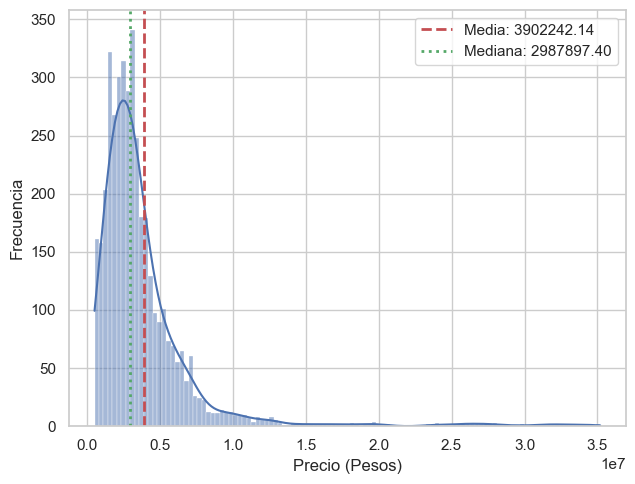

In [57]:
plot_histograms(df_outliers, [COLS.TARGET])


In [58]:
df_outliers[COLS.TARGET].median()

np.float64(2987897.40257824)

# PCA

In [59]:
df.columns

Index(['id_grid', 'STotalM2', 'SConstrM2', 'Dormitorios', 'Banos', 'Ambientes',
       'Amoblado', 'Antiguedad', 'Cisterna', 'BusinessCenter', 'Gimnasio',
       'Laundry', 'Calefaccion', 'AireAC', 'Recepcion', 'Estacionamiento',
       'Jacuzzi', 'AreaJuegosInfantiles', 'Seguridad', 'Pileta', 'Cocheras',
       'EstacionamientoVisitas', 'CanchaTennis', 'ITE_ADD_CITY_NAME',
       'ITE_ADD_STATE_NAME', 'ITE_ADD_NEIGHBORHOOD_NAME', 'ITE_TIPO_PROD',
       'LONGITUDE', 'LATITUDE', 'precio_pesos_constantes', 'year', 'SUM',
       'mes_listing'],
      dtype='object')

In [67]:
PCA_FEATURES = [
    COLS.SUP_TOTAL,
    COLS.SUP_CONSTR,
    COLS.DORMITORIOS,
    COLS.BANOS,
    COLS.AMBIENTES,
    COLS.ANTIGUEDAD,
    COLS.LATITUD,
    COLS.LONGITUD,
    COLS.COCHERAS,
] + BOOLEAN_COLS

In [68]:
# normalizamos features ordinales
df_pca, _ = standardize_features(df_std, [COLS.BANOS, COLS.AMBIENTES, COLS.COCHERAS, COLS.DORMITORIOS])

Standardizing columns: Banos, Ambientes, Cocheras, Dormitorios


In [81]:
X_pca = df_pca[PCA_FEATURES]
y_pca = df_pca[TARGET]

In [82]:
# Imputación simple para que PCA funcione
pca_imputer = SimpleImputer(strategy="median")
X_pca_imputed = pca_imputer.fit_transform(X_pca)
X_pca_imputed = pd.DataFrame(X_pca_imputed, columns=X_pca.columns, index=X_pca.index)

In [83]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_pca_imputed)

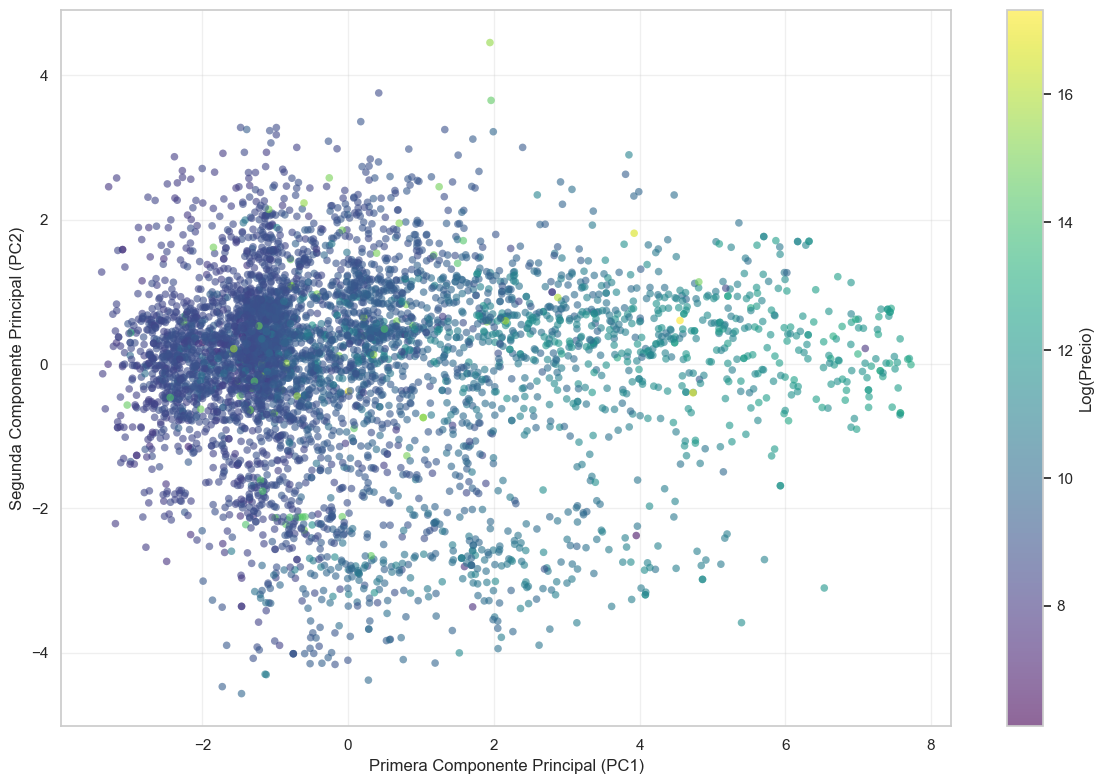

In [90]:
plot_pca_scatter(X_pca_2d, y_pca, filename="eda/12-pca-precio")

In [91]:
# Cuánta varianza explica cada componente
print(
    f"PC1 explica: {pca_2d.explained_variance_ratio_[0]:.3f} ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)"
)
print(
    f"PC2 explica: {pca_2d.explained_variance_ratio_[1]:.3f} ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)"
)
print(f"Total: {pca_2d.explained_variance_ratio_.sum():.3f}")

PC1 explica: 0.460 (46.0%)
PC2 explica: 0.153 (15.3%)
Total: 0.613


In [92]:
# Ver qué features contribuyen más a cada componente
loadings = pca_2d.components_.T  # Transponer para tener features x components
feature_names = X_pca.columns

# PC1: características que más contribuyen
pc1_contributions = pd.Series(loadings[:, 0], index=feature_names).sort_values(key=abs)
print("PC1 - Top contribuciones:")
print(pc1_contributions.tail(8))

# PC2: características que más contribuyen
pc2_contributions = pd.Series(loadings[:, 1], index=feature_names).sort_values(key=abs)
print("\nPC2 - Top contribuciones:")
print(pc2_contributions.tail(8))

PC1 - Top contribuciones:
Laundry        0.068951
LATITUDE       0.092134
Cocheras       0.313111
Banos          0.389052
Dormitorios    0.412548
Ambientes      0.420347
STotalM2       0.426410
SConstrM2      0.434514
dtype: float64

PC2 - Top contribuciones:
SUM           -0.044298
Pileta        -0.065910
Ambientes      0.098568
Dormitorios    0.102589
Antiguedad     0.240289
Cocheras      -0.246337
LATITUDE      -0.627337
LONGITUDE      0.676657
dtype: float64


Las propiedades hacia la derecha tienen:
- Más superficie (STotalM2, SConstrM2)
- Más ambientes, dormitorios, baños
- Más cocheras
Y en el scatter podemos ver que son las propiedades más caras.

El eje y está más relacionado con la ubicación


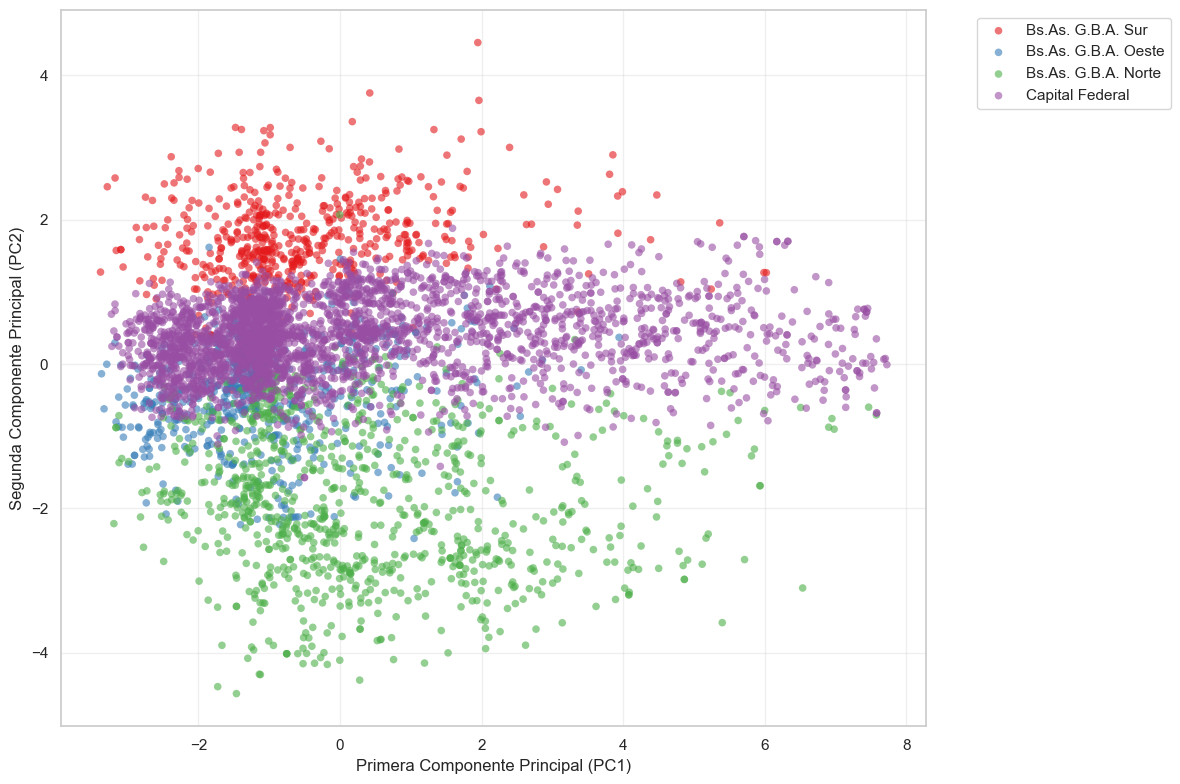

In [93]:
plot_pca_scatter(X_pca_2d, df_pca[COLS.PROVINCIA], filename="eda/12-pca-ciudad")

Acá queda bien claro que el eje y está relacionado con la ubicación.